## **README: Napari Image Processing Pipeline**

Loads a raw calcium-imaging timelapse (`.imgdir` frame dump), previews it in
napari, runs a lazy (dask-backed) denoise → background-normalise →
motion-correct pipeline, then supports manual ROI drawing (napari Labels layer,
saved/loaded as `.tiff`) and per-ROI brightness → dF/F trace extraction (§4).

### **1. Dependencies**

Run this notebook with the **`cascade` conda environment**
(`/Users/leolopster/miniconda3/envs/cascade`), which already provides every
package used here — it is *not* the `cascadetorch-env` from the repo's
`environment.yml`. Select that env's Python (or its Jupyter kernel) when
running:

```
conda activate cascade
```

- `napari` (+ Qt backend) — interactive viewer
- `dask` — lazy/out-of-core array stacking (`dask.array`, `dask.delayed`)
- `scikit-image` — `skimage.registration.phase_cross_correlation`;
  `skimage.restoration.denoise_nl_means` / `estimate_sigma` (denoise
  method `"nlm"`)
- `scipy` — `scipy.ndimage.gaussian_filter` (denoise method `"gaussian"`),
  `scipy.ndimage.shift`, `scipy.ndimage.percentile_filter` (dF/F baseline),
  `scipy.fft.dctn`/`idctn` (denoise method `"dct"`)
- `tifffile` — STD projection + ROI-mask `.tiff` I/O (§4)
- `zarr` — chunked on-disk store for the saved preprocessed stack (§3)
- `PyYAML` — parse `ElapsedTimes.yaml` for the real acquisition time axis
- `numpy`, `matplotlib` — array handling and static plotting
- `tqdm` *(optional)* — trace-extraction progress bar; degrades gracefully

Run in **JupyterLab/Notebook with the `%gui qt6` magic**, which starts a Qt
event loop so the napari window stays interactive alongside the notebook.

### **2. Usage / steps**

Run cells top to bottom; each section builds on viewer/array state from the
previous one.

1. **Create napari instance** — `%gui qt6`, then `napari.Viewer()` opens the
   viewer window (`viewer`).
2. **Open files** — point `data_dir` at a SlideBook-style `*.imgdir` export
   (see §3), glob `ImageData_Ch0_TP*.npy` in timepoint order, and load the
   first frame directly with `viewer.add_image()` as a sanity check.
   - **Max projection**: a plain-Python loop takes an elementwise max across
     every frame (loads each fully into memory, one at a time) and plots it
     with matplotlib for a quick static preview.
   - **Lazy stack**: wraps each frame load in `dask.delayed` and
     `da.stack`s them into one `(n_timepoints, height, width)` dask array
     (`raw_stack`) *without* reading the data.
3. **Preprocessing** — chained lazily per-frame so the full stack is never
   materialized at once (files can exceed RAM): denoise (`DENOISE_METHOD`) →
   background-normalise (`BACKGROUND_PERCENTILE`) → rigid motion correction.
   Result (`preprocessed_stack`) is added to napari; a max projection is
   plotted for QC.
   - **Save / load**: `preprocessed_stack` can be streamed to a chunked Zarr
     store under `_preprocessed/`; in later sessions run the load cell instead
     of the denoising cell to skip preprocessing entirely.
4. **ROI selection & trace extraction** — manual, napari-Labels-based:
   1. **STD projection** — `preprocessed_stack[::5].std(axis=0)` highlights
      temporally-fluctuating (active) pixels; added as `"preprocessed_std"`,
      saved to `_projections/`, and histogrammed for QC. Reference layer for
      drawing.
   2. **ROI mask (create / load / save)** — three independent cells on a
      napari **Labels** layer (`viewer.add_labels`): (a) create a blank layer
      and hand-paint ROIs with the brush tool; (b) load an existing mask from
      `_labels/<tag>_ROI.tiff`; (c) save the current layer back to `.tiff`.
   3. **Brightness traces** — per-ROI mean-intensity trace over the full time
      axis, streamed one dask frame at a time; time axis in seconds from
      `ElapsedTimes.yaml`.
   4. **dF/F + QC plots** — dF/F via a rolling low-percentile baseline
      (`BASELINE_PERCENTILE`, `BASELINE_WINDOW_S`), shown as (A) a dF/F
      spectrograph (ROI × time heatmap, `magma`) and (B) tightly-stacked
      per-ROI dF/F line charts.
   - *Not yet implemented (stubs):* PCA grouping (v) and PCA-distance graph
     (vi).

### **3. Image format**

- **Input**: a SlideBook-exported `*.imgdir` directory containing
  `ImageData_Ch0_TP########.npy` (one file per timepoint, shape `(1, H, W)`,
  `uint16`; observed `(1024, 1376)` after dropping the plane axis), per-frame
  `HistogramData_*` (unused), and `*.yaml` metadata. `ElapsedTimes.yaml` (a
  leading frame-count entry, then per-frame elapsed times in ms) *is* parsed in
  §4 to build the seconds time axis; the rest are not.
- **In-memory/lazy**: raw and preprocessed stacks are dask arrays of shape
  `(n_timepoints, height, width)`, chunked one frame at a time; preprocessing
  casts to `float32`.

### **4. Output format**

- **Persisted to disk**:
  - `_preprocessed/<tag>_<method>.zarr` (+ a `.params.json` sidecar) — the full
    preprocessed stack (§3), streamed one frame per chunk. Lets future sessions
    skip the denoise+motion-correction step via the §3 load cell.
  - `_projections/<tag>_std_projection.tiff` — STD projection of the
    preprocessed stack (`tifffile`, §4).
  - `_labels/<tag>_ROI.tiff` — hand-drawn ROI Labels mask (`uint16`,
    `tifffile`, §4), the round-trip artifact for manual ROI selection.
- **In-memory only**: `raw_stack`, per-ROI `roi_traces` and `dff_traces`.
- Static QC figures (max/STD projections, STD histogram, dF/F spectrograph,
  stacked dF/F traces) are rendered inline via matplotlib, not saved to file.
- No spike-inference step is run here — it only prepares the imaging stack and
  per-ROI traces. Per `CLAUDE.md`, keep raw and processed data separate from any
  later inferred-spike output, and log preprocessing parameters (`DENOISE_METHOD`
  + method-specific params, `BACKGROUND_PERCENTILE`, and the §4
  `BASELINE_PERCENTILE` / `BASELINE_WINDOW_S`) alongside saved results.

## **1. Create Napari instance**

In [1]:
# Open GUI magic command
%gui qt6

In [2]:
# Open napari
from skimage import data
import napari

viewer = napari.Viewer()

In [3]:
# Visualising images using matplotlib
import matplotlib.pyplot as plt

## **2. Open Files**

**Directory:**

`./leftDRGcut-1769167239-383.imgdir`<br>
`./Debi_DRG-Streamtodisk-1769166699-997.imgdir`

### **Loader**

In [28]:
from pathlib import Path

# Select local file directory
DATA_DIR = Path("./datasets/Debi_DRG-Streamtodisk-1769166699-997.imgdir")

In [7]:
# Load the first image file
import numpy as np

image_files = sorted(DATA_DIR.glob("ImageData_Ch0_TP*.npy"))
print(f"Found {len(image_files)} timepoints")

first_frame = np.load(image_files[0])[0]  # drop the singleton plane axis
print(first_frame.shape, first_frame.dtype)

# Visualise the first image file
viewer.add_image(first_frame, name="frame_0000")

Found 3220 timepoints
(1024, 1376) uint16


<Image layer 'frame_0000 [1]' at 0x1059ce710>

Loads image files onto Napari. Note that a Napari window should have popped up and now displaying the selected images.

In [8]:
# Load the filestack with lazy loading enabled
import dask
from dask import delayed
import dask.array as da

@delayed
def load_frame(path):
    return np.load(path)[0]


frame_shape = first_frame.shape
frame_dtype = first_frame.dtype

lazy_frames = [
    da.from_delayed(load_frame(f), shape=frame_shape, dtype=frame_dtype)
    for f in image_files
]
raw_stack = da.stack(lazy_frames, axis=0)
print(raw_stack)  # (n_timepoints, height, width) -- not yet loaded into memory

viewer.add_image(raw_stack, name="raw_stack")

dask.array<stack, shape=(3220, 1024, 1376), dtype=uint16, chunksize=(1, 1024, 1376), chunktype=numpy.ndarray>


<Image layer 'raw_stack' at 0x31ea50a60>

### **Max Projection (Optional)**

In [9]:
# Produce a max-stacked image from raw dataset
original_max_stack = np.zeros(first_frame.shape, dtype=first_frame.dtype)
for f in image_files:
    frame = np.load(f)[0]
    np.maximum(original_max_stack, frame, out=original_max_stack)

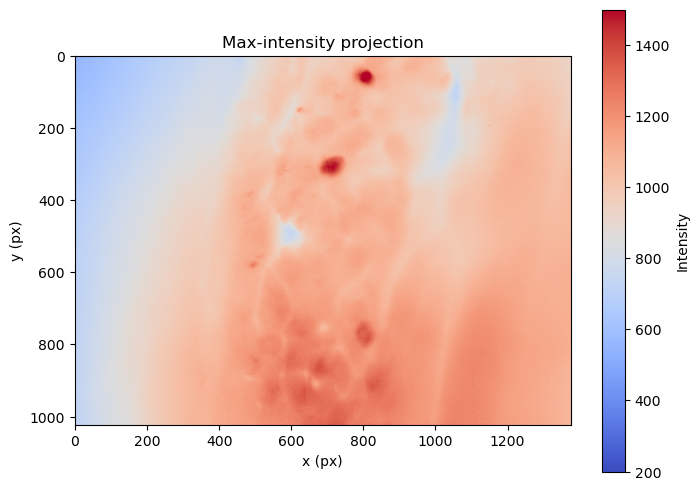

AGX: exceeded compiled variants footprint limit
2026-08-03 12:58:33.355 python[48482:6362231] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


In [20]:
# Plot Figure
plt.figure(figsize=(8, 6))
plt.imshow(original_max_stack, cmap="coolwarm", vmin=200, vmax=1500)
plt.colorbar(label="Intensity")
plt.title("Max-intensity projection")
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.show()

## **3. Preprocessing**

**Steps:**
1) Denoising — set `DENOISE_METHOD` to one of:
   - `"gaussian"` (default) — `scipy.ndimage.gaussian_filter`, `DENOISE_SIGMA`
   - `"nlm"` — non-local means, `skimage.restoration.denoise_nl_means`
     ([example](https://scikit-image.org/docs/stable/auto_examples/filters/plot_nonlocal_means.html)),
     noise level auto-estimated per-frame via `skimage.restoration.estimate_sigma`
   - `"dct"` — discrete cosine transform hard-thresholding via `scipy.fft.dctn`/`idctn`,
     `DCT_THRESHOLD_FRACTION`
2) Normalise to Background
3) Motion Correction

Note that files may be larger than RAM size.

### **Preprocess Settings**

In [32]:
# CONSTANTS
DENOISE_METHODS = ("gaussian", "nlm", "dct")
DENOISE_METHOD = "gaussian,nlm"  # comma separated methods, all indicated methods are used

DENOISE_SIGMA = 3.0  # gaussian

NLM_PATCH_SIZE = 5  # nlm: size (px) of patches used for patch distance comparison
NLM_PATCH_DISTANCE = 6  # nlm: max px distance to search for similar patches
NLM_H_FACTOR = 1.15  # nlm: cut-off distance, scaled by the estimated noise sigma

DCT_THRESHOLD_FRACTION = 0.0005  # dct: coefficients below this fraction of the max |coefficient| are zeroed

BACKGROUND_PERCENTILE = 6 # for normalisation

### **Run Denoising**

In [33]:
# Denoising, background normalisation and motion correction, chained lazily
# so the full (n_timepoints, height, width) stack is never held in RAM at once.
from scipy.ndimage import gaussian_filter, shift as nd_shift
from scipy.fft import dctn, idctn
from skimage.registration import phase_cross_correlation
from skimage.restoration import denoise_nl_means, estimate_sigma


def denoise_frame_gaussian(frame, sigma=DENOISE_SIGMA):
    return gaussian_filter(frame, sigma=sigma)


def denoise_frame_nlm(frame, patch_size=NLM_PATCH_SIZE, patch_distance=NLM_PATCH_DISTANCE, h_factor=NLM_H_FACTOR):
    # https://scikit-image.org/docs/stable/auto_examples/filters/plot_nonlocal_means.html
    sigma_est = estimate_sigma(frame, channel_axis=None)
    return denoise_nl_means(
        frame,
        h=h_factor * sigma_est,
        sigma=sigma_est,
        fast_mode=True,
        patch_size=patch_size,
        patch_distance=patch_distance,
        channel_axis=None,
    )


def denoise_frame_dct(frame, threshold_fraction=DCT_THRESHOLD_FRACTION):
    # Whole-frame 2D DCT. Hard-threshold small-magnitude AC coefficients
    # (high-frequency noise), then invert. The DC coefficient (frame mean
    # intensity) is excluded from the threshold scale and never dropped --
    # it's usually 100-1000x larger than any AC term, so including it made
    # the threshold zero out nearly the whole AC spectrum, collapsing the
    # frame to a flat constant.
    coeffs = dctn(frame, norm="ortho")
    ac_max = np.abs(coeffs.flat[1:]).max()
    threshold = threshold_fraction * ac_max
    mask = np.abs(coeffs) < threshold
    mask[0, 0] = False
    coeffs[mask] = 0
    return idctn(coeffs, norm="ortho")


_DENOISE_FUNCS = {
    "gaussian": denoise_frame_gaussian,
    "nlm": denoise_frame_nlm,
    "dct": denoise_frame_dct,
}


def denoise_frame(frame, method=DENOISE_METHOD):
    # method is a comma-separated list, e.g. "gaussian,nlm" -> applied in sequence.
    methods = [m.strip() for m in method.split(",")]
    methods = [m for m in methods if m]  # drop empty entries from stray/trailing commas
    if not methods:
        raise ValueError(f"DENOISE_METHOD must name at least one of {DENOISE_METHODS}, got {method!r}")
    unknown = [m for m in methods if m not in _DENOISE_FUNCS]
    if unknown:
        raise ValueError(
            f"Unknown DENOISE_METHOD entr{'y' if len(unknown) == 1 else 'ies'} {unknown!r}, "
            f"expected one of {DENOISE_METHODS}"
        )
    for single_method in methods:
        frame = _DENOISE_FUNCS[single_method](frame)
    return frame


def normalise_to_background(frame, background_percentile=BACKGROUND_PERCENTILE):
    background = np.percentile(frame, background_percentile)
    return frame.astype(np.float32) - background


# Reference frame for rigid motion correction, computed once and kept in memory
reference = normalise_to_background(denoise_frame(first_frame.astype(np.float32)))


@dask.delayed
def preprocess_frame(path, reference):
    frame = np.load(path)[0].astype(np.float32)
    frame = denoise_frame(frame)
    frame = normalise_to_background(frame)
    frame_shift, _, _ = phase_cross_correlation(reference, frame, upsample_factor=10)
    frame = nd_shift(frame, frame_shift)
    frame = np.clip(frame, 0, None)
    return frame.astype(np.float32)


lazy_preprocessed = [
    da.from_delayed(preprocess_frame(f, reference), shape=reference.shape, dtype=np.float32)
    for f in image_files
]
preprocessed_stack = da.stack(lazy_preprocessed, axis=0)

viewer.add_image(preprocessed_stack, name=f"preprocessed_{DENOISE_METHOD}")

<Image layer 'preprocessed_gaussian,nlm' at 0x320dc4f10>

### **Max Projection (Optional)**

In [15]:
# dask-compatible max projection (works for both dask arrays and numpy arrays)
import dask.array as da

In [16]:
def max_stack(input_stack):
    first_frame = input_stack[0]
    output_img = np.zeros(first_frame.shape, dtype=first_frame.dtype)
    for img in input_stack:
        np.maximum(output_img, img, out=output_img)
    return output_img

In [17]:
# lazy dask max along time axis -> (height, width) dask array
print("> 'processed_stack' is Dask array")

preprocessed_max_stack = preprocessed_stack[::5].max(axis=0)
print("> Image stacking complete")

# optionally compute to a numpy array: 
# preprocessed_max_stack = preprocessed_max_stack.compute()
viewer.add_image(preprocessed_max_stack, name="preprocessed_max")

> 'processed_stack' is Dask array
> Image stacking complete


<Image layer 'preprocessed_max' at 0x336456d40>

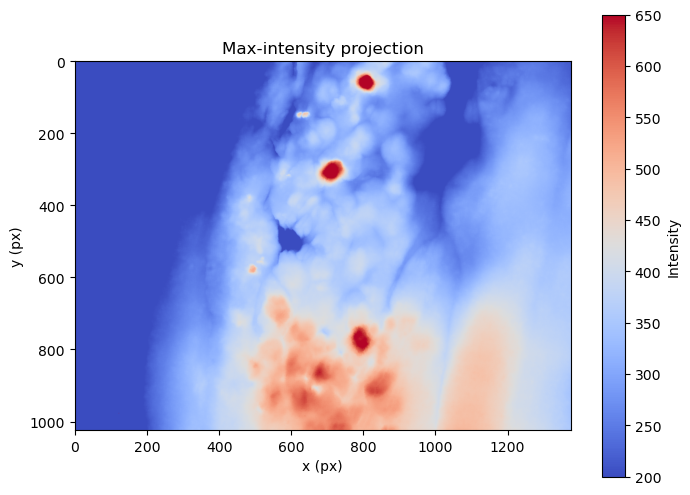

In [ ]:
# Plot Figure
plt.figure(figsize=(8, 6))
plt.imshow(
    preprocessed_max_stack,
    cmap="coolwarm", vmin=200, vmax=650,
    )
plt.colorbar(label="Intensity")
plt.title("Max-intensity projection")
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.show()

### **Save Preprocessed Stack**

***!!! WARNING: VERY TIME CONSUMING !!! Run the SAVE block only ONCE to cache the deck.***

- **Save** (run once): Streams the stack to a chunked Zarr store under
  `_preprocessed/` (one frame per chunk, so the full ~18 GB float32 stack is
  never held in RAM at once), and logs the preprocessing parameters beside it.
- **Load** (future sessions): Rebuilds a lazy `preprocessed_stack` straight from
  the Zarr store. Requires the §2 loader cells (`data_dir`, `image_files`,
  `first_frame`) and the **Preprocess Settings** cell to have run first.

In [29]:
PREPROCESSED_DIR = Path("./preprocessed/")
PREPROCESSED_DIR.mkdir(exist_ok=True)

In [ ]:
# SAVE (run once): persist the preprocessed stack to a chunked Zarr store so
# future sessions can skip preprocessing. Streamed one frame at a time -- the
# full (n_timepoints, H, W) float32 stack is never materialised in RAM at once.
import json as _json
from dask.diagnostics import ProgressBar

dataset_tag = DATA_DIR.name.split("-")[0]        # "Debi_DRG" from the .imgdir name
method_tag = DENOISE_METHOD.replace(",", "-").replace(" ", "")  # "gaussian,nlm" -> "gaussian-nlm"
preprocessed_zarr_path = PREPROCESSED_DIR / f"{dataset_tag}_{method_tag}.zarr"

# Preprocessing parameters logged alongside the data (CLAUDE.md 4).
preprocessed_params = {
    "dataset": DATA_DIR.name,
    "n_timepoints": int(preprocessed_stack.shape[0]),
    "frame_shape": list(preprocessed_stack.shape[1:]),
    "DENOISE_METHOD": DENOISE_METHOD,
    "DENOISE_SIGMA": DENOISE_SIGMA,
    "NLM_PATCH_SIZE": NLM_PATCH_SIZE,
    "NLM_PATCH_DISTANCE": NLM_PATCH_DISTANCE,
    "NLM_H_FACTOR": NLM_H_FACTOR,
    "DCT_THRESHOLD_FRACTION": DCT_THRESHOLD_FRACTION,
    "BACKGROUND_PERCENTILE": BACKGROUND_PERCENTILE,
}

# NOTE: this triggers the full preprocessing compute over every frame (slow).
with ProgressBar():
    preprocessed_stack.to_zarr(str(preprocessed_zarr_path), overwrite=True)

with open(preprocessed_zarr_path.with_suffix(".params.json"), "w") as f:
    _json.dump(preprocessed_params, f, indent=2)

print(f"> Saved preprocessed stack -> {preprocessed_zarr_path}")
print(f"> Params logged -> {preprocessed_zarr_path.with_suffix('.params.json')}")


[########################################] | 100% Completed | 368.41 s
> Saved preprocessed stack -> /Users/leolopster/Desktop/spike_inference/_preprocessed/Debi_DRG_gaussian-nlm.zarr
> Params logged -> /Users/leolopster/Desktop/spike_inference/_preprocessed/Debi_DRG_gaussian-nlm.params.json


### **Load Preprocessed Stack**

In [45]:
# LOAD (future sessions): run this INSTEAD of the "Run Denoising" cell to
# rebuild a lazy preprocessed_stack from disk, skipping preprocessing entirely.
# Needs the §2 loader (data_dir) and Preprocess Settings (DENOISE_METHOD) cells.
import dask.array as da

dataset_tag = DATA_DIR.name.split("-")[0]
method_tag = DENOISE_METHOD.replace(",", "-").replace(" ", "")
preprocessed_zarr_path = (
    PREPROCESSED_DIR
    / f"{dataset_tag}_{method_tag}.zarr"
)
print(preprocessed_zarr_path)

preprocessed_stack = da.from_zarr(str(preprocessed_zarr_path))
print(f"> Loaded preprocessed stack {preprocessed_stack.shape} {preprocessed_stack.dtype} "
      f"from {preprocessed_zarr_path}")

viewer.add_image(preprocessed_stack, name=f"preprocessed_{DENOISE_METHOD}")


preprocessed/Debi_DRG_gaussian-nlm.zarr
> Loaded preprocessed stack (3220, 1024, 1376) float32 from preprocessed/Debi_DRG_gaussian-nlm.zarr


<Image layer 'preprocessed_gaussian,nlm [1]' at 0x33623b2e0>

## **4. ROI Selection**

In [43]:
# Import for ROI Selection
import tifffile

Manually select ROI's based on the max stack created under §3, Max Projection (Optional).

### i. Save standard deviation (STD)-stacked image... (Deprecated)

### ii. Load in the ROI mask on top of the stacked image

**Run this to save options**

In [47]:
# Shared ROI-mask I/O settings for the create / load / save cells below.
LABELS_DIR = Path("./labels")
LABELS_DIR.mkdir(exist_ok=True)

# Base image layer whose shape/scale/translate the ROI Labels layer must match.
# "preprocessed_std" (temporal fluctuation) drives ROI drawing better than the
# max projection; swap here if you prefer another layer.
REFERENCE_IMAGE_LAYER = "preprocessed_max"

# Default load/save path, following the existing `_labels/<name>_ROI.tiff` convention.
ROI_MASK_PATH = LABELS_DIR / f"{dataset_tag}_ROI.tiff"

#### **(a) Create a new blank ROI Labels layer** — paint ROIs by hand with napari's brush tool.

In [20]:
# (a) Create a blank Labels layer sized to the reference image, then paint
# ROIs onto it with the napari brush tool (press `m` for a fresh label id
# per ROI). Run this OR the load cell below -- not both.
ref_layer = viewer.layers[REFERENCE_IMAGE_LAYER]
ref_shape = ref_layer.data.shape[-2:]

blank_mask = np.zeros(ref_shape, dtype=np.uint16)

roi_labels = viewer.add_labels(
    blank_mask,
    name="ROI mask",
    opacity=0.6,
    scale=tuple(np.atleast_1d(getattr(ref_layer, "scale", (1, 1)))[-2:]),
    translate=tuple(np.atleast_1d(getattr(ref_layer, "translate", (0, 0)))[-2:]),
)
print(f"> Created blank 'ROI mask' ({ref_shape[0]}x{ref_shape[1]}) matching "
      f"'{REFERENCE_IMAGE_LAYER}' -- paint ROIs with the brush tool.")

> Created blank 'ROI mask' (1024x1376) matching 'preprocessed_std' -- paint ROIs with the brush tool.


#### **(b) Load an existing ROI mask (`.tiff`)** — reads a rasterised Labels mask from disk and overlays it on the reference layer.

In [48]:
# (b) Load an existing ROI mask. Default location:
#     /Users/leolopster/Desktop/spike_inference/_labels/<dataset_tag>_ROI.tiff
mask = tifffile.imread(ROI_MASK_PATH)
print(f"> Loaded mask {mask.shape} {mask.dtype} from {ROI_MASK_PATH}; "
      f"{len(np.unique(mask)) - 1} ROI(s) found")

ref_layer = viewer.layers[REFERENCE_IMAGE_LAYER]
ref_shape = ref_layer.data.shape[-2:]
if mask.shape != ref_shape:
    raise ValueError(
        f"Loaded mask shape {mask.shape} != '{REFERENCE_IMAGE_LAYER}' shape {ref_shape}; "
        "check ROI_MASK_PATH / REFERENCE_IMAGE_LAYER."
    )

roi_labels = viewer.add_labels(
    mask.astype(np.uint16),
    name="ROI mask",
    opacity=0.6,
    scale=tuple(np.atleast_1d(getattr(ref_layer, "scale", (1, 1)))[-2:]),
    translate=tuple(np.atleast_1d(getattr(ref_layer, "translate", (0, 0)))[-2:]),
)

> Loaded mask (1024, 1376) int64 from labels/Debi_DRG_ROI.tiff; 59 ROI(s) found


#### **(c) Save the current ROI Labels layer** — writes the painted/edited mask back to `ROI_MASK_PATH`.

In [22]:
# (c) Save the current ROI Labels layer back to disk as a .tiff.
roi_labels = viewer.layers["ROI mask"]  # the Labels layer created/edited above

tifffile.imwrite(ROI_MASK_PATH, roi_labels.data.astype(np.uint16))
print(f"> Saved 'ROI mask' ({roi_labels.data.shape}, "
      f"{len(np.unique(roi_labels.data)) - 1} ROI(s)) -> {ROI_MASK_PATH}")

> Saved 'ROI mask' ((1024, 1376), 40 ROI(s)) -> /Users/leolopster/Desktop/spike_inference/_labels/Debi_DRG_ROI.tiff


### iii. Create brightness traces along the time axis for each ROI, based on `preprocessed_stack`

In [67]:
# Real per-frame acquisition times (seconds) from the .imgdir metadata, used as
# the shared time axis for every trace plot below. ElapsedTimes.yaml stores a
# list whose first entry is the frame count, followed by one elapsed time (ms)
# per frame.
import yaml

with open(DATA_DIR / "ElapsedTimes.yaml") as f:
    _elapsed = yaml.safe_load(f)["theElapsedTimes"]

times_ms = np.asarray(_elapsed[1:], dtype=float)  # drop leading count entry
n_timepoints = preprocessed_stack.shape[0]
if len(times_ms) != n_timepoints:
    # Fall back to a nominal 10 Hz axis if metadata length disagrees with the stack.
    print(f"! ElapsedTimes has {len(times_ms)} entries but stack has {n_timepoints} frames; "
          "falling back to a nominal 10 Hz time axis.")
    times_s = np.arange(n_timepoints, dtype=float) / 10.0
else:
    times_s = (times_ms - times_ms[0]) / 1000.0

print(f"> Time axis: {n_timepoints} frames, {times_s[-1]:.1f} s total, "
      f"~{1.0 / np.median(np.diff(times_s)):.1f} Hz median")

> Time axis: 3220 frames, 322.2 s total, ~10.0 Hz median


In [98]:
# Select starting timepoint and number of timepoints to extract
START_TIMEPOINT = 0
EXTRACT_TIMEPOINTS = 500

# Check validity of timepoint configuration
START_TIMEPOINT = int(max(0, START_TIMEPOINT))
EXTRACT_TIMEPOINTS = int(max(0, EXTRACT_TIMEPOINTS))

# Per-ROI mean-intensity (brightness) trace over the full time axis, streamed
# one dask frame at a time so the whole (n_timepoints, H, W) float32 stack is
# never materialised in RAM at once.
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

def extract_roi_traces(stack, mask, start_t, extract_timepoints):
    """Return {roi_id: (n_timepoints,) float32 mean-intensity trace}."""
    n_t = min(stack.shape[0], start_t + extract_timepoints)
    roi_ids = [int(r) for r in np.unique(mask) if r != 0]
    # Precompute pixel indices per ROI once -- avoids re-masking every frame.
    roi_indices = {roi_id: np.where(mask == roi_id) for roi_id in roi_ids}
    traces = {roi_id: np.zeros(n_t, dtype=np.float32) for roi_id in roi_ids}

    for t in tqdm(range(start_t, start_t + n_t), desc="Extracting ROI traces"):
        frame = np.asarray(stack[t])  # materialise exactly one frame
        for roi_id in roi_ids:
            yy, xx = roi_indices[roi_id]
            traces[roi_id][t] = frame[yy, xx].mean()
    return traces


roi_mask = viewer.layers["ROI mask"].data
roi_traces = extract_roi_traces(preprocessed_stack, roi_mask, START_TIMEPOINT, EXTRACT_TIMEPOINTS)
print(f"> Extracted {len(roi_traces)} ROI traces (Starting from timepoint {START_TIMEPOINT}, {EXTRACT_TIMEPOINTS} timepoints each)")

Extracting ROI traces: 100%|██████████| 500/500 [00:03<00:00, 152.26it/s]

> Extracted 59 ROI traces (Starting from timepoint 0, 500 timepoints each)


### iv. Create dF/F (F: brightness) traces for each ROI from obtained brightness traces

In [99]:
# No. of slides at the beginning of each trace used to calculate the baseline F0
BASELINE_SLIDES = 20

# Calculate dF/F for each ROI
dff_dict = {}
for roi, trace in roi_traces.items():
    f0 = np.average(trace[:BASELINE_SLIDES])
    new_trace = (trace - f0) / f0
    dff_dict[roi] = new_trace

# Stack into a (n_rois, n_timepoints) matrix for the plots below. np.array on
# dict_values gives a 0-d object array, so go via an explicit ordered list --
# roi_ids fixes the row order and labels every plot consistently.
roi_ids = sorted(dff_dict)
dff_matrix = np.vstack([dff_dict[roi] for roi in roi_ids])

# The traces cover only the extracted window (START_TIMEPOINT, EXTRACT_TIMEPOINTS),
# which is shorter than the full ElapsedTimes axis -- clip times_s to match.
t_plot = times_s[START_TIMEPOINT:START_TIMEPOINT + dff_matrix.shape[1]]

print(f"> dF/F for {len(roi_ids)} ROI(s) x {dff_matrix.shape[1]} frames "
      f"({t_plot[0]:.1f}-{t_plot[-1]:.1f} s); "
      f"range [{dff_matrix.min():.2f}, {dff_matrix.max():.2f}]")

> dF/F for 59 ROI(s) x 500 frames (0.0-49.9 s); range [-0.17, 1.15]


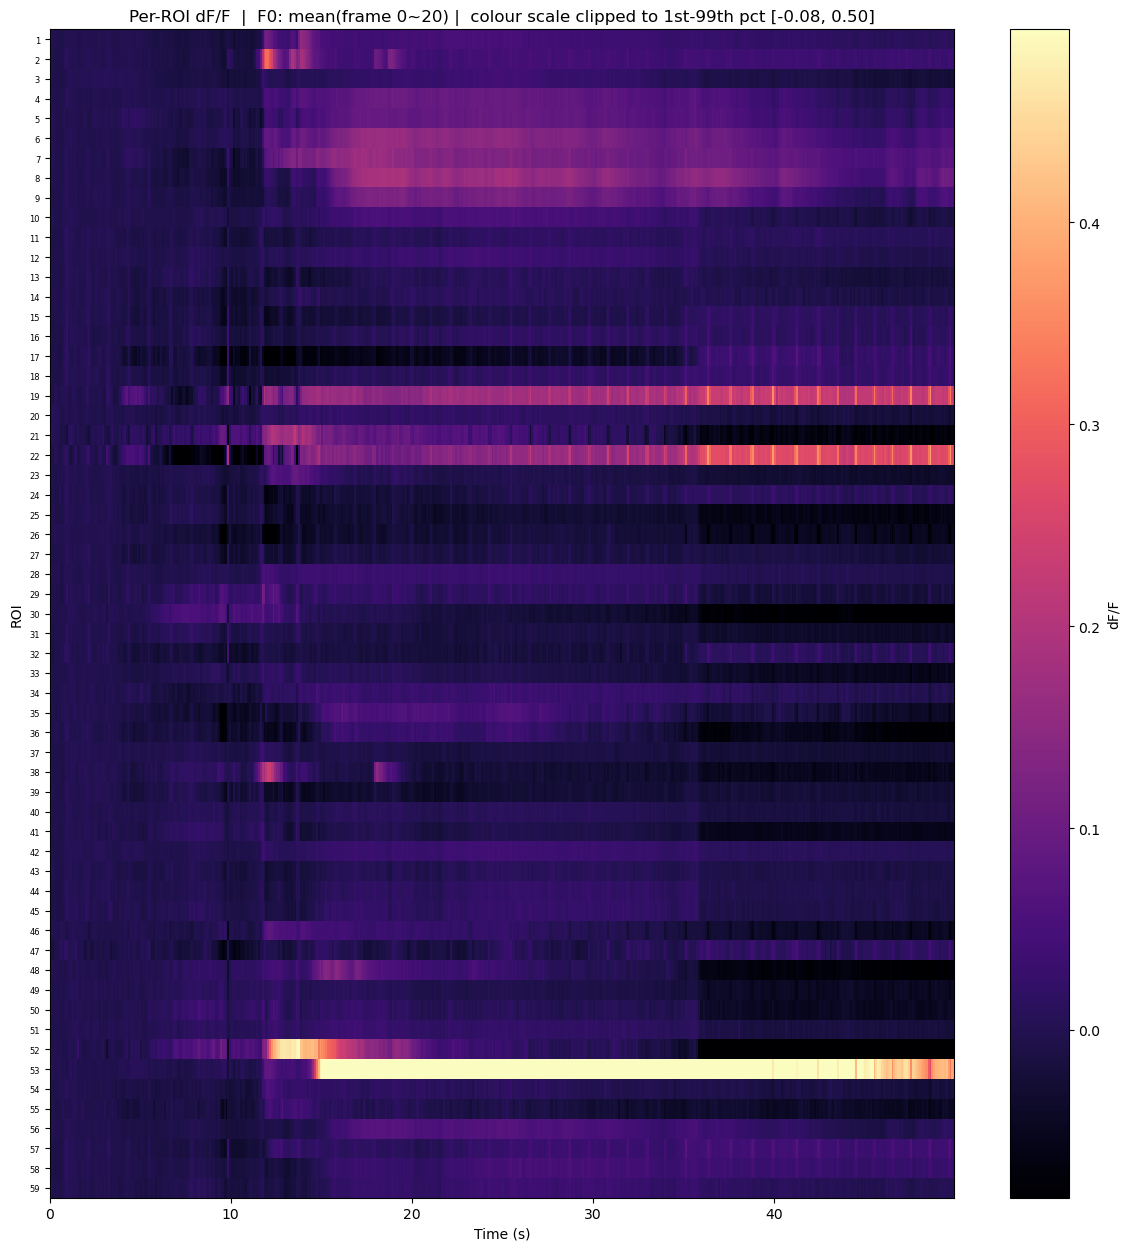

In [101]:
# QC plot A -- dF/F spectrograph: one row per ROI, x = time (s), pixel = dF/F.
# Rows come from dff_dict via roi_ids/dff_matrix (F0 = mean of the first
# BASELINE_SLIDES frames). magma (perceptually uniform) per CLAUDE.md 5; jet is avoided.

# Robust colour limits -- without them a couple of large transients compress
# every other ROI to black. The scale is clipped, not neutral, so it is stated
# in the title.
vmin, vmax = np.percentile(dff_matrix, [1, 99])

fig, ax = plt.subplots(figsize=(12, 0.18 * len(roi_ids) + 2))
im = ax.imshow(
    dff_matrix,
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
    extent=[t_plot[0], t_plot[-1], len(roi_ids) - 0.5, -0.5],
)
ax.set_yticks(range(len(roi_ids)))
ax.set_yticklabels([str(r) for r in roi_ids], fontsize=6)
ax.set_xlabel("Time (s)")
ax.set_ylabel("ROI")
ax.set_title(
    f"Per-ROI dF/F  |  F0: mean(frame 0~{BASELINE_SLIDES}) |  "
    f"colour scale clipped to 1st-99th pct [{vmin:.2f}, {vmax:.2f}]"
)
fig.colorbar(im, ax=ax, label="dF/F")
plt.tight_layout()
plt.show()


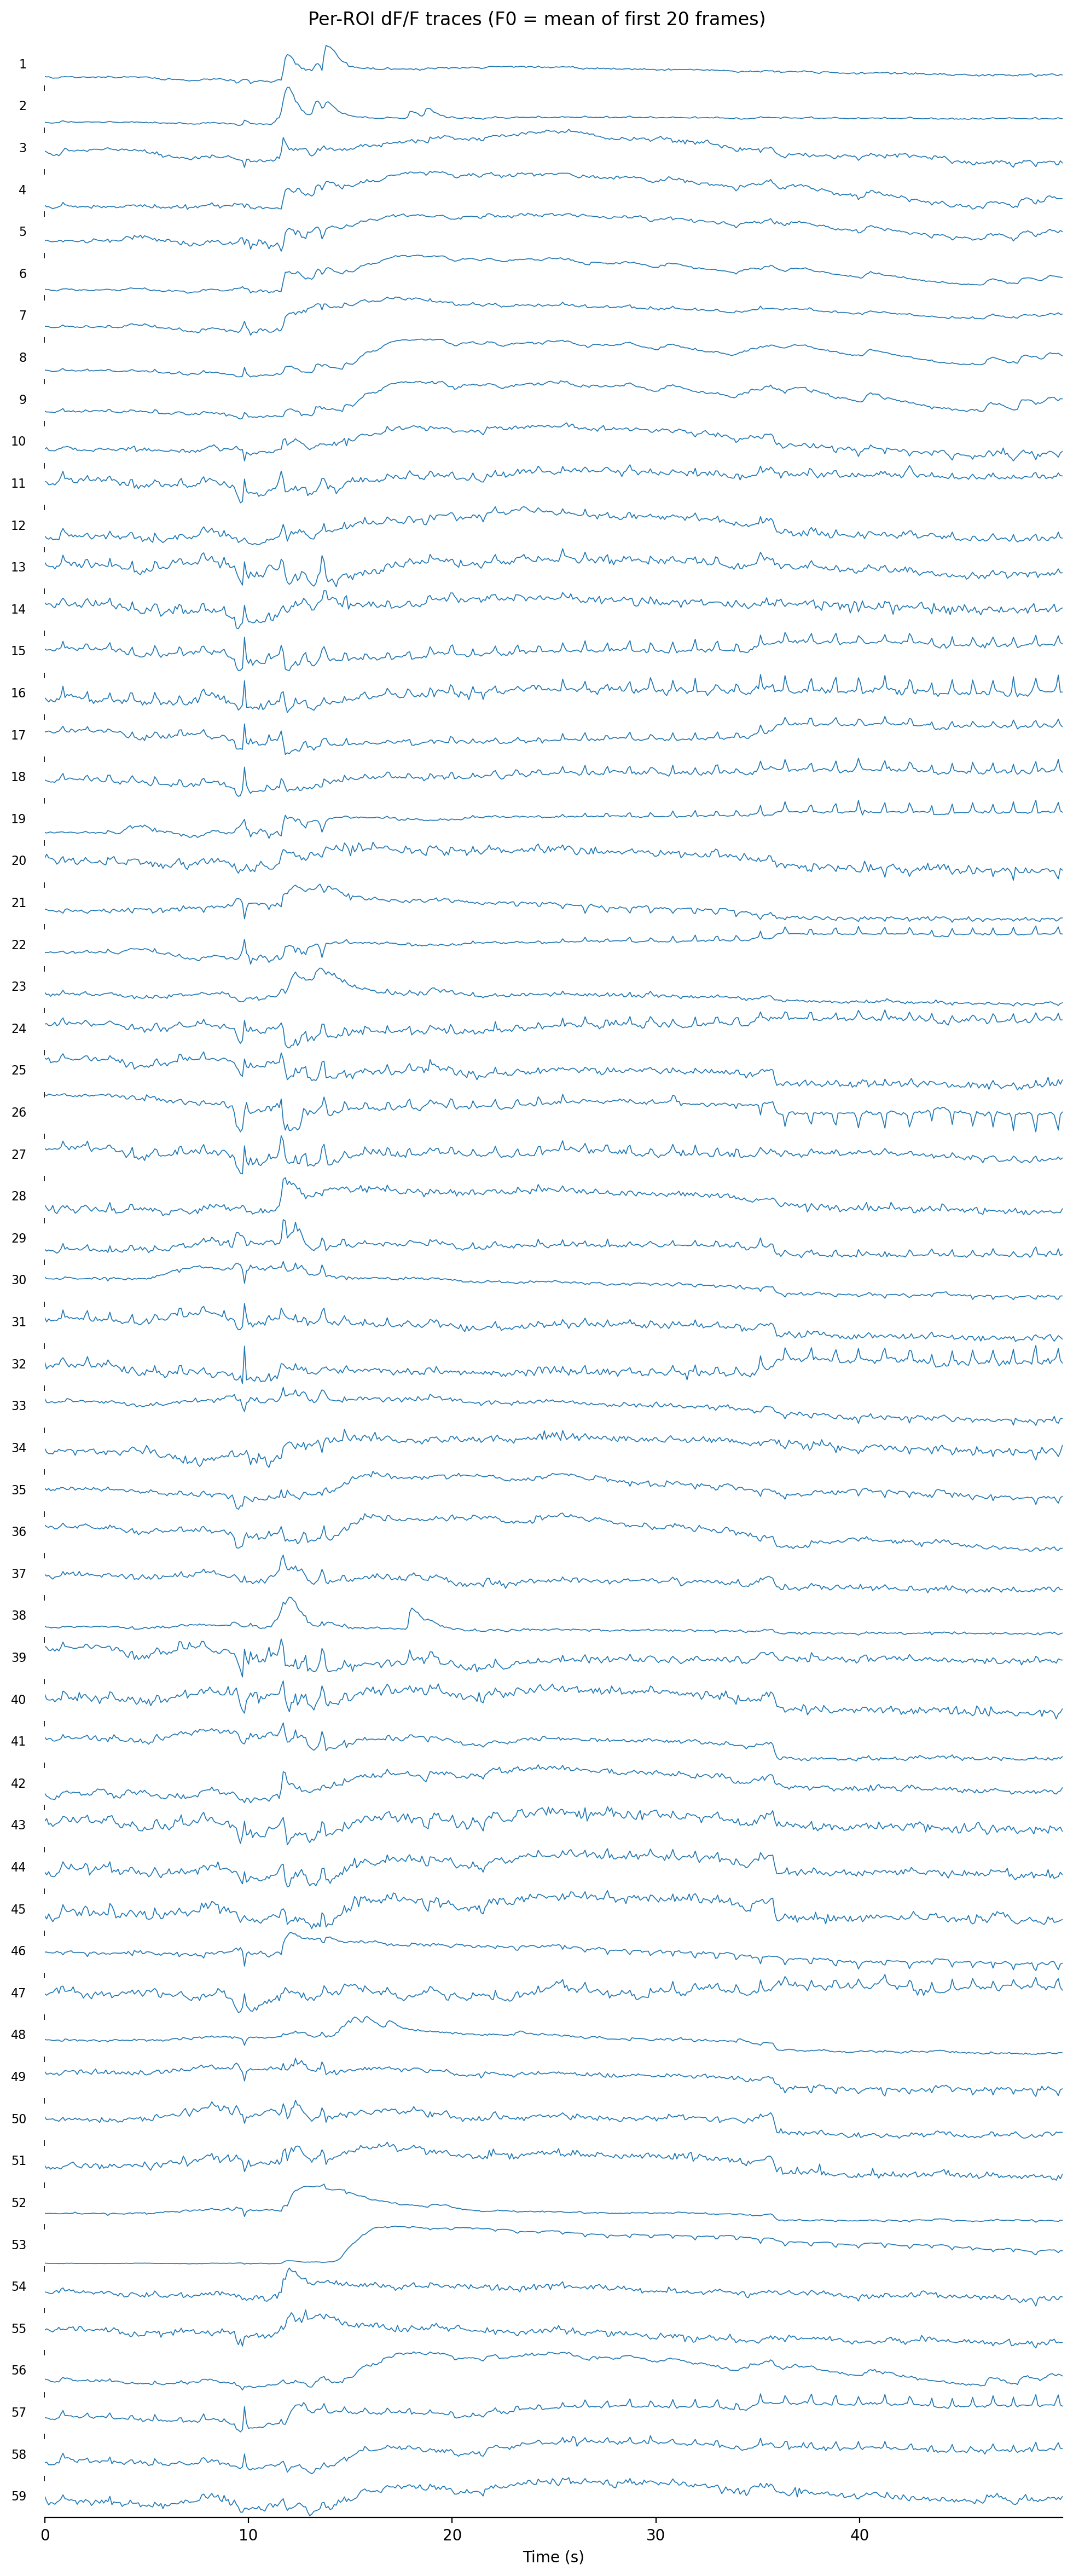

In [113]:
# QC plot B -- stacked dF/F line charts: one subplot per ROI, tightly stacked,
# trace only (no grid, no spines/ticks), ROI number in the left padding.
n_rois = len(roi_ids)
fig_h = 0.4 * n_rois
fig, axes = plt.subplots(
    n_rois, 1, sharex=True, figsize=(12, fig_h), dpi=200
)
axes = np.atleast_1d(axes)

# Margins in absolute inches, converted to figure fractions. matplotlib's
# defaults are fractions (top=0.88), so on a figure whose height grows with
# n_rois they turn into inches of blank space above the first trace.
TOP_IN, BOTTOM_IN = 0.45, 0.55  # room for the suptitle / the shared x-axis
fig.subplots_adjust(
    hspace=0,
    top=1 - TOP_IN / fig_h,
    bottom=BOTTOM_IN / fig_h,
)

for ax, roi_id in zip(axes, roi_ids):
    ax.plot(t_plot, dff_dict[roi_id], linewidth=0.6)
    ax.margins(x=0)
    ax.set_yticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.set_ylabel(str(roi_id), rotation=0, ha="right", va="center", labelpad=12, fontsize=8)

# only the bottom subplot carries the shared time axis
axes[-1].spines["bottom"].set_visible(True)
axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Per-ROI dF/F traces (F0 = mean of first {BASELINE_SLIDES} frames)",
    y=1 - 0.15 / fig_h, va="top",
)
plt.show()


## **5. Analysis and Summary**

Groups the ROIs in `dff_matrix` by **when** they respond and **how fast** they fluctuate, in
two independent passes over the same neurons:

- **Index A — inferred spike rate.** CASCADE converts each dF/F trace into an inferred rate;
  that rate is summarised per stimulus phase, then PCA + hierarchical clustering groups the
  ROIs. *Reported first.*
- **Index B — event frequency.** Per-phase FFT band powers of the same inferred rate, fed to
  a **separate** PCA + clustering on the same ROIs.

The two indices are kept in separate PCAs on purpose: pooling rate and frequency features
into one decomposition yields PCs that are a blend of both and can be read as neither. §5 x
compares the two groupings at the end.

| Phase | Window | Note |
|---|---|---|
| pre | 2–10 s | starts at 2 s to exclude the frames that defined F0 |
| stim | 10–15 s | shortest phase — sets the 0.2 Hz frequency resolution floor |
| post | 15–50 s | truncated to ~49.9 s by `EXTRACT_TIMEPOINTS`; contains the decay tail |

**Requires** §4 iv to have run (`dff_matrix`, `roi_ids`, `t_plot`, `BASELINE_SLIDES`).
**Outputs** go to `analysis/<dataset_tag>/`: `spike_rate.npy`, `spike_inference_params.json`,
`rate_features.csv`, `freq_features.csv`, `roi_groups.csv`.

Read §5 xi before quoting any number out of this section.


In [114]:
# §5 i. Stimulus phase windows, shared by everything below.
# `pre` starts at 2.0 s, not 0 s: frames 0..BASELINE_SLIDES defined F0, so dF/F over
# that span is ~0 by construction and would fake a perfectly silent baseline.
PHASES = {
    "pre": (2.0, 10.0),
    "stim": (10.0, 15.0),
    "post": (15.0, 50.0),
}
PHASE_ORDER = list(PHASES)

FRAME_RATE = 1.0 / float(np.median(np.diff(t_plot)))
phase_masks = {name: (t_plot >= t0) & (t_plot < t1) for name, (t0, t1) in PHASES.items()}

for name in PHASE_ORDER:
    mask = phase_masks[name]
    if not mask.any():
        raise ValueError(f"Phase '{name}' {PHASES[name]} contains no frames of t_plot.")
    print(f"> {name:<5} requested {PHASES[name][0]:>5.1f}-{PHASES[name][1]:<5.1f} s | "
          f"realised {t_plot[mask][0]:>5.1f}-{t_plot[mask][-1]:<5.1f} s, {mask.sum():>3} frames")

overlap = sum(m.sum() for m in phase_masks.values())
print(f"> {overlap} frames assigned across {len(PHASES)} disjoint phases; "
      f"recording ends at {t_plot[-1]:.1f} s, frame rate {FRAME_RATE:.2f} Hz")
if PHASES["post"][1] > t_plot[-1]:
    print(f"! post requested to {PHASES['post'][1]:.0f} s but the extraction stops at "
          f"{t_plot[-1]:.1f} s -- report the post window as 15-{t_plot[-1]:.1f} s.")


> pre   requested   2.0-10.0  s | realised   2.0-9.9   s,  80 frames
> stim  requested  10.0-15.0  s | realised  10.0-14.9  s,  50 frames
> post  requested  15.0-50.0  s | realised  15.0-49.9  s, 350 frames
> 480 frames assigned across 3 disjoint phases; recording ends at 49.9 s, frame rate 10.00 Hz
! post requested to 50 s but the extraction stops at 49.9 s -- report the post window as 15-49.9 s.


### ii. CASCADE (Spike Inference Model)

[CASCADE](https://github.com/HelmchenLabSoftware/Cascade) (Rupprecht et al., 2021) is a CNN
ensemble that converts a dF/F trace into an inferred spike rate. The local `CascadeTorch/`
copy is used; nothing is downloaded.

- **Do not call `cascade.download_model()`.** All 24 model folders already carry their `.pth`
  weights on disk — that call only needs network access and would fail offline.
- **OpenMP workaround.** `import torch` aborts in the `cascade` env with `OMP: Error #15`
  (two copies of `libomp.dylib`). `os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"` is set
  *before* the import in the run cell. Inference runs on CPU — the workload is 59 x 500.
- **Edge padding.** The model needs a 32-frame window centred on each prediction point, so
  the first and last **16 frames (1.6 s)** come back `NaN`. That does not touch the 2–10 s
  pre window, but it does trim ~1.6 s off the end of the post window. Everything downstream
  uses `np.nanmean` / `np.nanmax`.
- **Units.** CASCADE returns spikes *per frame*; multiplying by the frame rate gives
  **spikes/s**. Output is a continuous rate, not discrete events — no threshold is applied.
- **Noise levels.** `calculate_noise_levels` reports in percent units and this model covers
  levels 2–30. Our traces are heavily denoised (gaussian σ=3 + NLM) and averaged over many
  pixels per ROI, so they may fall *below* 2 — in which case every ROI silently gets the
  lowest-noise ensemble. The run cell prints the levels so this is visible rather than assumed.
- **Model choice is a logged parameter**, not a default to inherit — see the selector below.


In [122]:
# §5 iii. Choose the pretrained CASCADE model. Every locally available model is
# listed with the properties that decide whether it is applicable at all: the rate
# it was trained at (taken from the model NAME) and the ground-truth datasets.
import re

CASCADE_DIR = Path("./CascadeTorch")
CASCADE_MODEL_DIR = CASCADE_DIR / "Pretrained_models"


def model_config(name):
    with open(CASCADE_MODEL_DIR / name / "config.yaml") as f:
        return yaml.safe_load(f)


def model_rate_from_name(name):
    """Training sampling rate parsed out of the model name itself.

    'Spinal_cord_excitatory_30Hz_smoothing50ms' -> 30.0
    'GC8_EXC_7.5Hz_smoothing100ms_high_noise'   -> 7.5
    """
    match = re.search(r"[_-](\d+(?:\.\d+)?)Hz", name)
    if not match:
        raise ValueError(f"No '<rate>Hz' token in model name {name!r}; cannot infer its "
                         "training rate. Rename the folder or pass the rate explicitly.")
    return float(match.group(1))


available_models = sorted(p.name for p in CASCADE_MODEL_DIR.iterdir() if p.is_dir())
print(f"{'model':<52}{'name':>6}{'cfg':>7}   training datasets")
for name in available_models:
    cfg = model_config(name)
    name_rate, cfg_rate = model_rate_from_name(name), float(cfg["sampling_rate"])
    flag = "" if np.isclose(name_rate, cfg_rate) else "   <-- MISMATCH"
    print(f"{name:<52}{name_rate:>6}{cfg_rate:>7}   "
          f"{', '.join(cfg['training_datasets'])}{flag}")

# ---------------- SELECT MODEL HERE ----------------
MODEL_NAME = "Spinal_cord_excitatory_30Hz_smoothing50ms"
# ---------------------------------------------------

model_cfg = model_config(MODEL_NAME)
MODEL_RATE = model_rate_from_name(MODEL_NAME)  # rate taken from the name

# At least one shipped folder is misnamed (GC8_EXC_15Hz_smoothing50ms_high_noise carries
# sampling_rate 10.0). Resampling to the wrong target silently corrupts everything
# downstream, so surface the disagreement rather than quietly picking a side.
if not np.isclose(MODEL_RATE, float(model_cfg["sampling_rate"])):
    print(f"\n! NAME/CONFIG MISMATCH for {MODEL_NAME}: the name says {MODEL_RATE} Hz, "
          f"config.yaml says {model_cfg['sampling_rate']} Hz. Resampling follows the NAME, "
          "but CASCADE reads the CONFIG internally -- resolve this before trusting the output.")

# Resampling plan (applied in §5 iv).
RESAMPLE_RATIO = MODEL_RATE / FRAME_RATE
NEEDS_RESAMPLE = not np.isclose(RESAMPLE_RATIO, 1.0)

print(f"\n> Selected: {MODEL_NAME}")
print(f"> Trained at {MODEL_RATE} Hz on {', '.join(model_cfg['training_datasets'])}; "
      f"smoothing {1000 * model_cfg['smoothing']:.0f} ms, window {model_cfg['windowsize']} frames")
if NEEDS_RESAMPLE:
    print(f"> Recording is {FRAME_RATE:.2f} Hz -> traces are resampled {RESAMPLE_RATIO:.4g}x to "
          f"{MODEL_RATE:.4g} Hz for inference, then the inferred rate is resampled back to "
          f"{FRAME_RATE:.2f} Hz so every window downstream stays on the real acquisition grid.")
    if RESAMPLE_RATIO > 1:
        print("! Upsampling adds NO information. The interpolated trace is smoother than "
              "anything the model saw in training and its frame-to-frame noise is "
              f"artificially low (§5 iv passes noise levels measured at {FRAME_RATE:.2f} Hz to "
              f"compensate). True resolution stays {FRAME_RATE:.2f} Hz / "
              f"{FRAME_RATE / 2:.2f} Hz Nyquist regardless of the {MODEL_RATE:.4g} Hz label.")
else:
    print("> Recording rate already matches the model; no resampling needed.")
if "GCaMP6" in " ".join(model_cfg["training_datasets"]):
    print("! Indicator mismatch: this model was trained on GCaMP6, this recording is GCaMP8. "
          "GCaMP6-tuned models misestimate rate at both ends on GCaMP8 (CLAUDE.md App.A 4C) -- "
          "the trade being made here is closer tissue for wrong indicator.")

model                                                 name    cfg   training datasets
GC8_EXC_100Hz_smoothing10ms                          100.0  100.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_10Hz_smoothing150ms_high_noise                10.0   10.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_10Hz_smoothing75ms_high_noise                 10.0   10.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_15Hz_smoothing100ms_high_noise                15.0   15.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_15Hz_smoothing50ms_high_noise                 15.0   10.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1   <-- MISMATCH
GC8_EXC_20Hz_smoothing30ms_high_noise                 20.0   20.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_20Hz_smoothing60ms_high_noise                 20.0   20.0   DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
GC8_EXC_30Hz_smoothing25ms_high

In [123]:
# §5 iv. Run CASCADE on dff_matrix -> inferred spike rate, resampling to the model's
# training rate and back again if they differ.
import os
import sys
import json
from fractions import Fraction

from scipy.signal import resample_poly

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # must be set BEFORE torch is imported
if str(CASCADE_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(CASCADE_DIR.resolve()))

import torch
from cascade2p import cascade
from cascade2p.utils import calculate_noise_levels


def resample_traces(traces, src_rate, dst_rate, max_denominator=1000):
    """Resample a (n_rois, n_frames) array along time from src_rate to dst_rate (Hz).

    Polyphase (`resample_poly`) rather than FFT resampling: the ratio is rational and
    small, and polyphase avoids the circular-convolution edge ringing that
    `scipy.signal.resample` produces on non-periodic calcium traces.

    NaN-safe -- NaNs are interpolated before filtering (an FIR would otherwise smear
    them across the whole trace) and the invalid mask is re-applied afterwards, so
    CASCADE's unpredictable edge frames stay marked as unpredictable.
    """
    x = np.asarray(traces, dtype=float)
    if x.ndim == 1:
        x = x[None, :]
    if np.isclose(src_rate, dst_rate):
        return x.copy()

    ratio = Fraction(dst_rate / src_rate).limit_denominator(max_denominator)
    up, down = ratio.numerator, ratio.denominator

    bad = ~np.isfinite(x)
    if bad.any():
        x = x.copy()
        idx = np.arange(x.shape[1])
        for i in range(x.shape[0]):
            m = bad[i]
            if m.all():
                x[i] = 0.0
            elif m.any():
                x[i, m] = np.interp(idx[m], idx[~m], x[i, ~m])

    y = resample_poly(x, up, down, axis=1)

    if bad.any():
        # nearest source frame for each output frame, so the invalid mask carries over
        src_idx = np.clip((np.arange(y.shape[1]) * down) // up, 0, x.shape[1] - 1)
        y[bad[:, src_idx]] = np.nan
    return y


# Noise level decides which ensemble each ROI is sent to. It MUST be measured on the
# native-rate traces: the metric is a median frame-to-frame difference, and interpolated
# frames are correlated by construction, so measuring it after upsampling reports a
# far-too-clean trace and sends every ROI to the wrong ensemble.
noise_levels = calculate_noise_levels(dff_matrix, FRAME_RATE)
model_noise = np.asarray(model_cfg["noise_levels"], dtype=float)
print(f"> Noise levels at the native {FRAME_RATE:.2f} Hz (percent units): "
      f"median {np.median(noise_levels):.2f}, "
      f"range [{noise_levels.min():.2f}, {noise_levels.max():.2f}]")
print(f"> Model covers noise levels {model_noise.min():.0f}-{model_noise.max():.0f}; "
      f"{int((noise_levels < model_noise.min()).sum())} ROI(s) below, "
      f"{int((noise_levels > model_noise.max()).sum())} above -> clamped to the nearest ensemble.")

if NEEDS_RESAMPLE:
    traces_for_model = resample_traces(dff_matrix, FRAME_RATE, MODEL_RATE)
    naive = calculate_noise_levels(traces_for_model, MODEL_RATE)
    print(f"> Resampled traces for inference: {dff_matrix.shape} @ {FRAME_RATE:.2f} Hz "
          f"-> {traces_for_model.shape} @ {MODEL_RATE:.4g} Hz")
    print(f"> (measuring noise AFTER resampling would have given median {np.median(naive):.2f} "
          f"instead of {np.median(noise_levels):.2f} -- the native value is passed instead)")
else:
    traces_for_model = dff_matrix

spike_prob_model = cascade.predict(
    MODEL_NAME,
    traces_for_model,
    model_folder=str(CASCADE_MODEL_DIR),
    padding=np.nan,
    trace_noise_levels=noise_levels,  # measured natively, see above
    device=torch.device("cpu"),
)

# spikes/frame -> spikes/s. Rate is an intensity, not a count, so it survives
# resampling unchanged in units -- which is why the conversion happens first.
spike_rate_model = spike_prob_model * MODEL_RATE

if NEEDS_RESAMPLE:
    spike_rate = resample_traces(spike_rate_model, MODEL_RATE, FRAME_RATE)
    # guard against an off-by-one from a non-integer ratio
    if spike_rate.shape[1] != dff_matrix.shape[1]:
        n = min(spike_rate.shape[1], dff_matrix.shape[1])
        print(f"! Resampled length {spike_rate.shape[1]} != {dff_matrix.shape[1]}; "
              f"trimming both to {n} frames.")
        spike_rate = spike_rate[:, :n]
    print(f"> Inferred at {MODEL_RATE:.4g} Hz {spike_rate_model.shape}, "
          f"resampled back to {FRAME_RATE:.2f} Hz {spike_rate.shape}")
else:
    spike_rate = spike_rate_model

PAD = int(np.isnan(spike_rate[0]).argmin())  # frames CASCADE could not predict, per end
print(f"\n> Inferred rate {spike_rate.shape}; {PAD} NaN frame(s) padded at each end "
      f"(= {PAD / FRAME_RATE:.1f} s)")
print(f"> Rate range [{np.nanmin(spike_rate):.3f}, {np.nanmax(spike_rate):.3f}] spikes/s")
if t_plot[PAD] > PHASES["pre"][0]:
    print(f"! Padding reaches {t_plot[PAD]:.1f} s, past the start of the pre window "
          f"({PHASES['pre'][0]} s) -- widen PHASES['pre'] or expect NaN-only frames there.")

# Persist the inference + its parameters (CLAUDE.md 4: log method + params beside output).
ANALYSIS_DIR = Path("./analysis") / dataset_tag
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
np.save(ANALYSIS_DIR / "spike_rate.npy", spike_rate)

with open(ANALYSIS_DIR / "spike_inference_params.json", "w") as f:
    json.dump({
        "dataset": DATA_DIR.name,
        "algorithm": "CASCADE (Rupprecht et al. 2021), CascadeTorch",
        "model_name": MODEL_NAME,
        "model_rate_hz_from_name": MODEL_RATE,
        "model_rate_hz_from_config": float(model_cfg["sampling_rate"]),
        "model_training_datasets": model_cfg["training_datasets"],
        "model_smoothing_s": model_cfg["smoothing"],
        "recording_frame_rate_hz": FRAME_RATE,
        "resampled": bool(NEEDS_RESAMPLE),
        "resample_ratio": RESAMPLE_RATIO,
        "resample_method": "scipy.signal.resample_poly (polyphase), NaN-preserving",
        "noise_levels_measured_at_hz": FRAME_RATE,
        "padding": "nan",
        "pad_frames_per_end": PAD,
        "roi_ids": [int(r) for r in roi_ids],
        "noise_levels": [float(x) for x in noise_levels],
        "phases_s": {k: list(v) for k, v in PHASES.items()},
        "BASELINE_SLIDES": BASELINE_SLIDES,
        "START_TIMEPOINT": START_TIMEPOINT,
        "EXTRACT_TIMEPOINTS": EXTRACT_TIMEPOINTS,
    }, f, indent=2)

print(f"> Saved spike_rate.npy + spike_inference_params.json -> {ANALYSIS_DIR}")

> Noise levels at the native 10.00 Hz (percent units): median 0.11, range [0.06, 0.30]
> Model covers noise levels 2-14; 59 ROI(s) below, 0 above -> clamped to the nearest ensemble.
> Resampled traces for inference: (59, 500) @ 10.00 Hz -> (59, 1500) @ 30 Hz
> (measuring noise AFTER resampling would have given median 0.03 instead of 0.11 -- the native value is passed instead)

 
The selected model was trained on 1 datasets, with 5 ensembles for each noise level, at a sampling rate of 30Hz, with a resampled ground truth that was smoothed with a Gaussian kernel of a standard deviation of 50 milliseconds. 
 

Loaded model was trained at frame rate 30 Hz
Given argument traces contains 59 neurons and 1500 frames.
Noise levels (mean, std; in standard units): 0.12, 0.04

Predictions for noise level 2:
	... ensemble 0
	... ensemble 1
	... ensemble 2
	... ensemble 3
	... ensemble 4

Predictions for noise level 3:
	No neurons for this noise level

Predictions for noise level 4:
	No neurons for t

In [141]:
# §5 v. Index A -- per-phase summary of the inferred rate, one row per ROI.
import pandas as pd

# spikes/s above which a frame counts as "active". A fixed absolute value does not
# transfer between models: the GC8 models floor at 0, the spinal-cord model never drops
# below ~0.3 spikes/s, so any constant is either above every peak or below every trough
# for one of them. Default is therefore derived from this recording's own pre-stimulus
# distribution (robust median + 3 sigma-equivalent MAD). Set a number to override.
# There is no field consensus on principled thresholding here (CLAUDE.md 6) -- this is a
# stated convention, not a validated criterion.
ACTIVE_THRESH = 0.4

if ACTIVE_THRESH is None:
    _base = spike_rate[:, phase_masks["pre"]]
    _med = np.nanmedian(_base)
    _mad = np.nanmedian(np.abs(_base - _med))
    ACTIVE_THRESH = float(_med + 3 * 1.4826 * _mad)
    print(f"> ACTIVE_THRESH auto = {ACTIVE_THRESH:.3f} spikes/s "
          f"(pre-phase median {_med:.3f} + 3x robust sigma {1.4826 * _mad:.3f})")

rate_features = pd.DataFrame(index=pd.Index(roi_ids, name="roi"))
dff_summary = pd.DataFrame(index=pd.Index(roi_ids, name="roi"))

for name in PHASE_ORDER:
    seg = spike_rate[:, phase_masks[name]]
    finite = np.isfinite(seg)
    # NaN-padded frames must not count as "inactive" -- mask them out rather than
    # letting the (NaN > thresh) -> False comparison silently deflate the fraction.
    active = np.where(finite, seg > ACTIVE_THRESH, np.nan)

    rate_features[f"rate_mean_{name}"] = np.nanmean(seg, axis=1)
    rate_features[f"rate_peak_{name}"] = np.nanmax(seg, axis=1)
    rate_features[f"rate_active_frac_{name}"] = np.nanmean(active, axis=1)

    # dF/F amplitude: reported for description, fed to NEITHER PCA. Amplitude is
    # not a rate proxy (CLAUDE.md App.A 11), and mixing it into the rate PCA
    # would also break the one-index-per-PCA rule this section is built on.
    dseg = dff_matrix[:, phase_masks[name]]
    dff_summary[f"dff_mean_{name}"] = dseg.mean(axis=1)
    dff_summary[f"dff_peak_{name}"] = dseg.max(axis=1)

# Integrated spike count is deliberately absent: it equals rate_mean x duration,
# so including it would just double the weight of rate_mean in the PCA.
n_bad = int((~np.isfinite(rate_features.to_numpy())).sum())
print(f"> Index A: {rate_features.shape[1]} features x {rate_features.shape[0]} ROIs "
      f"({n_bad} non-finite value(s) -- must be 0 before PCA)")

# Is ACTIVE_THRESH discriminating, or is it above/below everything?
for name in PHASE_ORDER:
    frac = rate_features[f"rate_active_frac_{name}"]
    print(f"> {name:<5} ACTIVE_THRESH={ACTIVE_THRESH:.3f}: {int((frac > 0).sum()):>2}/{len(frac)} "
          f"ROIs ever active, {int((frac == 1).sum())} always active")

constant = [c for c in rate_features.columns if rate_features[c].nunique() <= 1]
if constant:
    print(f"! Constant feature(s) {constant}: identical for every ROI, so they contribute "
          "nothing to the PCA (z-scoring leaves them at 0). Adjust ACTIVE_THRESH if the "
          "active-fraction columns are the ones flat-lining.")

print(rate_features.describe().loc[["mean", "min", "max"]].round(3).to_string())

> Index A: 9 features x 59 ROIs (0 non-finite value(s) -- must be 0 before PCA)
> pre   ACTIVE_THRESH=0.400: 49/59 ROIs ever active, 0 always active
> stim  ACTIVE_THRESH=0.400: 54/59 ROIs ever active, 8 always active
> post  ACTIVE_THRESH=0.400: 49/59 ROIs ever active, 4 always active
      rate_mean_pre  rate_peak_pre  rate_active_frac_pre  rate_mean_stim  rate_peak_stim  rate_active_frac_stim  rate_mean_post  rate_peak_post  rate_active_frac_post
mean          0.395          0.800                 0.240           0.656           1.811                  0.552           0.534           1.061                  0.397
min           0.311          0.363                 0.000           0.297           0.343                  0.000           0.275           0.321                  0.000
max           1.081          9.811                 0.775           2.754          10.528                  1.000           3.681           7.623                  1.000


> PCA-A: 9 features -> 3 PC(s) for 83% of variance


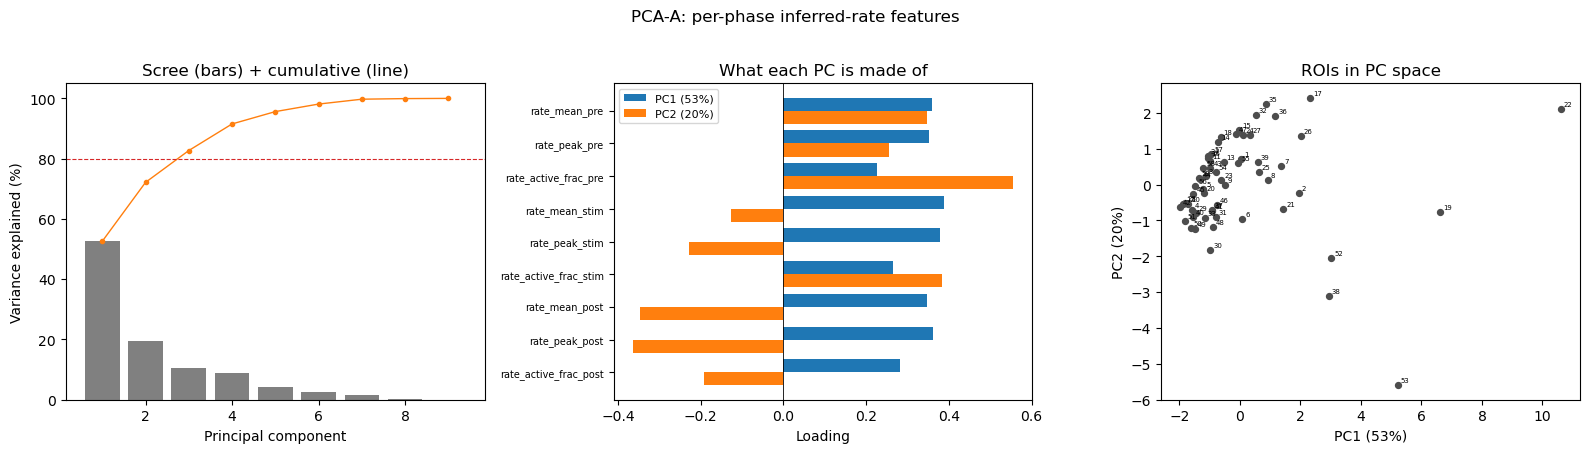


> Candidate cuts (pick one for RATE_CUT_HEIGHT below, or accept the auto choice):
   height   gap  smallest  largest                       sizes
k                                                             
2   15.72  7.84         6       53                     [53, 6]
3   11.50  0.60         1       53                  [53, 5, 1]
4    9.14  4.11         1       28              [28, 25, 5, 1]
5    6.44  1.29         1       28           [28, 25, 3, 2, 1]
6    5.44  0.72         1       28        [28, 16, 9, 3, 2, 1]
7    4.68  0.80         1       28     [28, 16, 9, 2, 2, 1, 1]
8    4.12  0.34         1       28  [28, 13, 9, 3, 2, 2, 1, 1]


In [142]:
# §5 vi. PCA-A on the rate features, plus the shared PCA/clustering machinery that
# Index B (§5 x) reuses -- same pipeline, different feature table, separate fit.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

PCA_VAR_TARGET = 0.80  # keep the PCs needed to reach this cumulative variance
MIN_GROUP_SIZE = 3     # a "group" of 1-2 ROIs is an outlier, not a population
MAX_GROUP_FRAC = 0.9   # ...and one group holding almost everything is not a partition


def pca_and_linkage(features, var_target=PCA_VAR_TARGET):
    """z-score -> PCA -> Ward linkage on the leading PCs. Returns (pca, scores, n_pc, Z)."""
    X = StandardScaler().fit_transform(features.to_numpy(dtype=float))
    pca = PCA().fit(X)
    scores = pca.transform(X)
    n_pc = int(np.searchsorted(np.cumsum(pca.explained_variance_ratio_), var_target) + 1)
    return pca, scores, n_pc, linkage(scores[:, :n_pc], method="ward")


def plot_pca_summary(pca, scores, features, title):
    var = pca.explained_variance_ratio_ * 100
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

    axes[0].bar(np.arange(1, len(var) + 1), var, color="0.5")
    axes[0].plot(np.arange(1, len(var) + 1), np.cumsum(var), marker="o", ms=3, lw=1, color="C1")
    axes[0].axhline(PCA_VAR_TARGET * 100, ls="--", lw=0.8, color="C3")
    axes[0].set_xlabel("Principal component")
    axes[0].set_ylabel("Variance explained (%)")
    axes[0].set_title("Scree (bars) + cumulative (line)")

    y = np.arange(len(features.columns))
    axes[1].barh(y - 0.2, pca.components_[0], height=0.4, label=f"PC1 ({var[0]:.0f}%)")
    axes[1].barh(y + 0.2, pca.components_[1], height=0.4, label=f"PC2 ({var[1]:.0f}%)")
    axes[1].set_yticks(y)
    axes[1].set_yticklabels(features.columns, fontsize=7)
    axes[1].axvline(0, color="k", lw=0.6)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Loading")
    axes[1].set_title("What each PC is made of")
    axes[1].legend(fontsize=8)

    axes[2].scatter(scores[:, 0], scores[:, 1], s=18, color="0.3")
    for i, roi in enumerate(roi_ids):
        axes[2].annotate(str(roi), (scores[i, 0], scores[i, 1]), fontsize=5,
                         xytext=(2, 2), textcoords="offset points")
    axes[2].set_xlabel(f"PC1 ({var[0]:.0f}%)")
    axes[2].set_ylabel(f"PC2 ({var[1]:.0f}%)")
    axes[2].set_title("ROIs in PC space")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def cut_candidates(Z, max_k=8):
    """Every cut from k=2..max_k with its height, merge gap and resulting group sizes.

    Printed so that "cut by inspection" (§5 vii) is an informed choice, not a guess.
    """
    rows = []
    for k in range(2, max_k + 1):
        lo, hi = Z[-k, 2], Z[-(k - 1), 2]
        height = 0.5 * (lo + hi)
        sizes = np.bincount(fcluster(Z, height, criterion="distance"))[1:]
        rows.append({"k": k, "height": round(float(height), 2), "gap": round(float(hi - lo), 2),
                     "smallest": int(sizes.min()), "largest": int(sizes.max()),
                     "sizes": list(map(int, sorted(sizes)[::-1]))})
    return pd.DataFrame(rows).set_index("k")


def suggest_cut(Z, max_k=8, min_group_size=MIN_GROUP_SIZE, max_group_frac=MAX_GROUP_FRAC):
    """Largest merge gap near the top of the tree, among cuts that actually partition.

    Two guards, because the plain largest-gap rule reliably returns a non-answer: it
    tends to slice off one extreme ROI and call the remaining 95% a single group. A cut
    is eligible only if every group holds >= `min_group_size` ROIs AND no group holds
    more than `max_group_frac` of them -- the same criterion §5 viii uses to declare a
    partition degenerate, applied up front instead of as a post-hoc complaint.
    """
    cand = cut_candidates(Z, max_k)
    n_rois = int(cand.iloc[0]["sizes"] and sum(cand.iloc[0]["sizes"]))
    usable = cand[(cand["smallest"] >= min_group_size)
                  & (cand["largest"] <= max_group_frac * n_rois)]
    if usable.empty:
        print(f"! No cut in k=2..{max_k} gives groups of >= {min_group_size} ROIs with none "
              f"exceeding {max_group_frac:.0%} of the population; falling back to the plain "
              "largest-gap cut (expect a degenerate partition).")
        usable = cand
    return float(usable.loc[usable["gap"].idxmax(), "height"])


def plot_dendrogram(Z, title, cut):
    fig, ax = plt.subplots(figsize=(13, 4.6))
    dendrogram(Z, labels=[str(r) for r in roi_ids], leaf_font_size=6,
               color_threshold=cut, above_threshold_color="0.65", ax=ax)
    ax.axhline(cut, ls="--", lw=1, color="C3")
    ax.set_xlabel("ROI")
    ax.set_ylabel("Ward merge cost")
    ax.set_title(f"{title}  (cut at h={cut:.2f})")
    plt.tight_layout()
    plt.show()


pca_rate, scores_rate, npc_rate, Z_rate = pca_and_linkage(rate_features)
print(f"> PCA-A: {rate_features.shape[1]} features -> {npc_rate} PC(s) "
      f"for {100 * pca_rate.explained_variance_ratio_[:npc_rate].sum():.0f}% of variance")
plot_pca_summary(pca_rate, scores_rate, rate_features,
                 "PCA-A: per-phase inferred-rate features")

print("\n> Candidate cuts (pick one for RATE_CUT_HEIGHT below, or accept the auto choice):")
print(cut_candidates(Z_rate).to_string())

### vii. How to read the dendrogram

The tree is built by **Ward linkage**: start with every ROI as its own cluster, then
repeatedly merge the two clusters whose merger increases within-cluster variance the least.

- **Leaves** (bottom) are individual ROIs, labelled by ROI id.
- **Height of a horizontal bar** = the *cost* of that merge, i.e. how much within-cluster
  variance the merge added. It is **not** the distance between two ROIs — a common
  misreading. Heights grow as you go up because later merges join bigger clusters.
- **A horizontal cut** at height *h* defines the groups: every branch still unbroken below
  the cut becomes one group. Cutting lower ⇒ more, tighter groups.
- **Long vertical stems** below a merge mean the two things being joined were very different
  — a well-separated group sits under a long stem. **Short stems** mean the group barely
  holds together and would dissolve at a slightly lower cut.
- **Left–right order of leaves carries no meaning.** Each merge can be drawn either way
  round, so "adjacent in the plot" does not imply "similar". Only vertical structure counts.

**Practical rule:** cut just below the largest vertical gap — the tallest stretch of tree
with no merges. That is the height where clusters stay stable over the widest range, so the
grouping is least sensitive to exactly where you cut.

The cells below print a **candidate-cut table** (`cut_candidates`) — for every k from 2 to 8:
the cut height, the merge gap, and the resulting group sizes. Read it alongside the tree.

`suggest_cut` picks the largest gap among the *eligible* cuts, where eligible means every
group holds at least `MIN_GROUP_SIZE` ROIs **and** no group holds more than
`MAX_GROUP_FRAC` of the population. Both guards exist because on this data the unguarded
largest-gap rule returns a non-answer: it slices off two or three extreme ROIs and calls the
remaining 95% "a group". If no cut qualifies, the fallback is the plain largest gap and the
next cell says so loudly.

To override, set `RATE_CUT_HEIGHT` / `FREQ_CUT_HEIGHT` to a height from the table and re-run —
the dashed red line in the plot shows where the cut landed.

**Caveat:** Ward assumes roughly spherical, similarly-sized clusters in the PCA space it is
given. It will always return a partition, including on data with no real group structure —
the dendrogram is a hypothesis to check against the group-mean traces below, not proof.

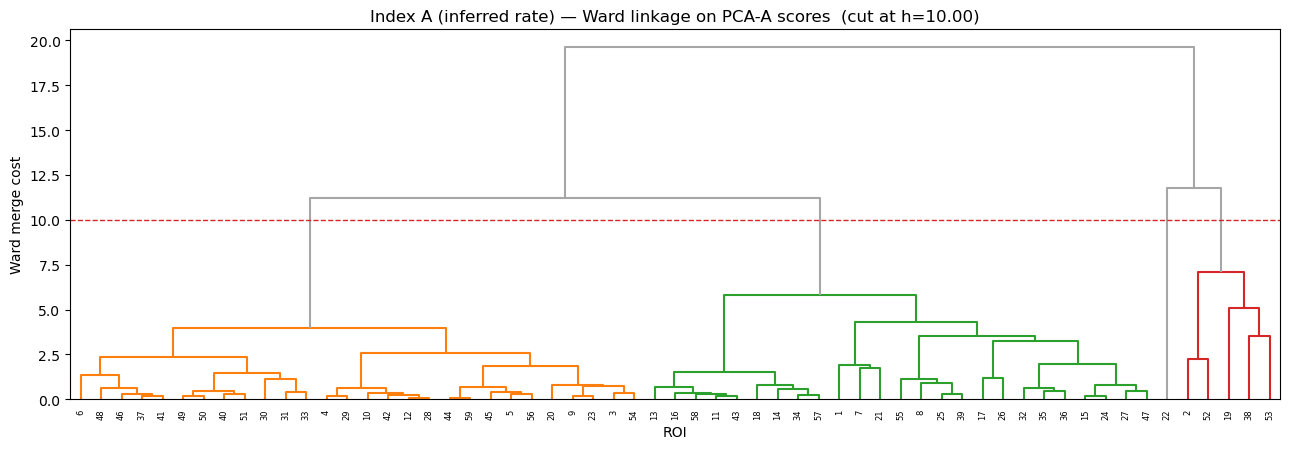

> Cut at h=10.00 -> 4 group(s): G1 n=28, G2 n=25, G3 n=5, G4 n=1


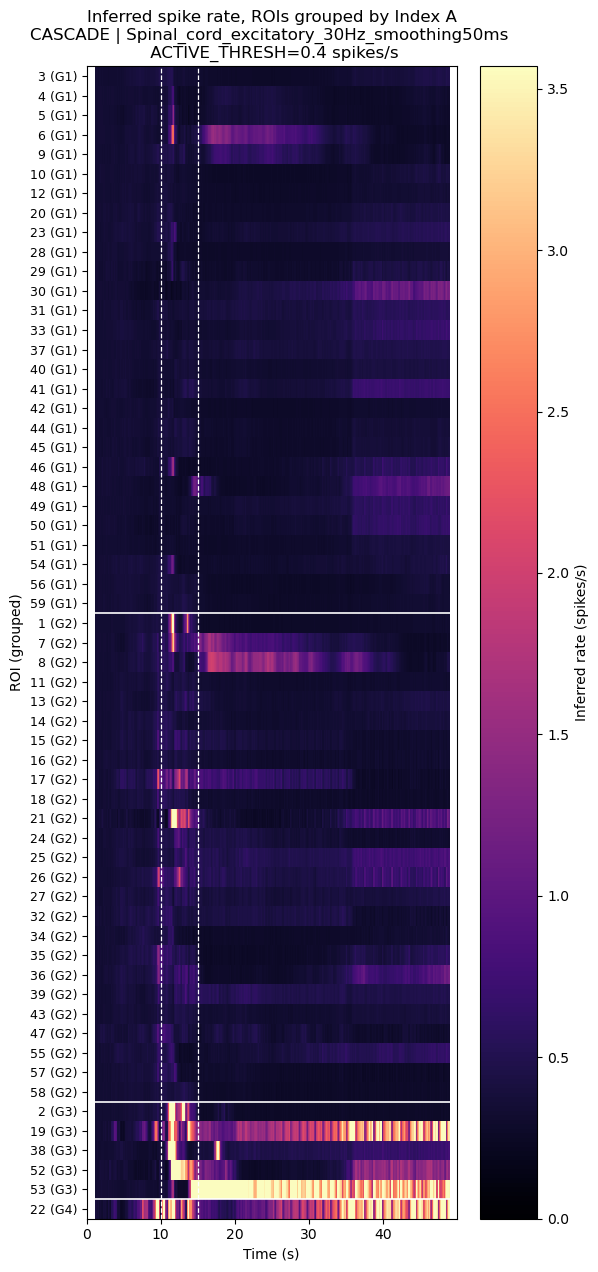

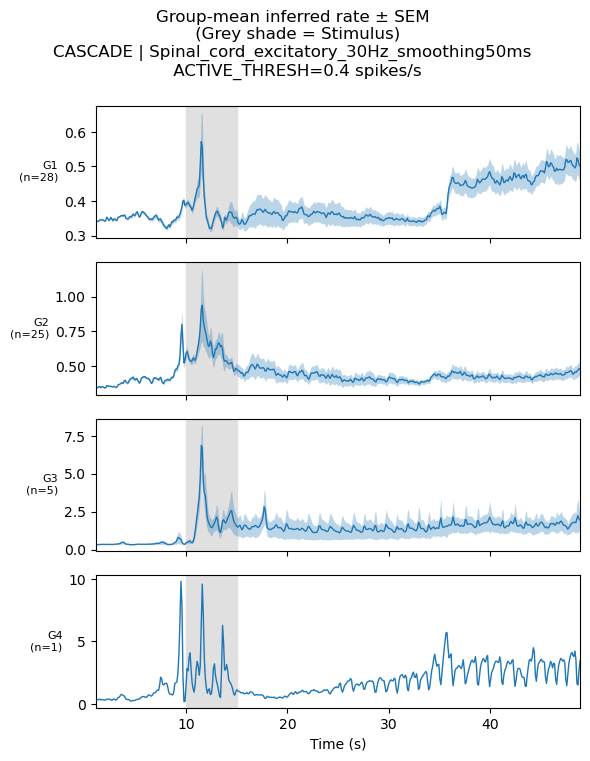


=== Rate groups (Index A) ===
CASCADE | Spinal_cord_excitatory_30Hz_smoothing50ms 
 ACTIVE_THRESH=0.4 spikes/s
       n_rois  rate_mean_pre  rate_peak_pre  dff_peak_pre  rate_mean_stim  rate_peak_stim  dff_peak_stim  rate_mean_post  rate_peak_post  dff_peak_post dominant_phase
group                                                                                                                                                                 
G1         28          0.352          0.428         0.020           0.380           0.683          0.048           0.402           0.624          0.051           post
G2         25          0.413          0.839         0.022           0.612           1.284          0.038           0.427           0.704          0.054           stim
G3          5          0.407          0.890         0.066           2.058           9.203          0.347           1.517           4.370          0.429           stim
G4          1          1.081          9.811         0

In [147]:
# §5 viii. Cut the rate tree into groups, then characterise what each group does.
RATE_CUT_HEIGHT = 10.0  # set a number (see the candidate table above) to cut manually

cut_rate = RATE_CUT_HEIGHT if RATE_CUT_HEIGHT is not None else suggest_cut(Z_rate)
plot_dendrogram(Z_rate, "Index A (inferred rate) — Ward linkage on PCA-A scores", cut_rate)

rate_groups = fcluster(Z_rate, cut_rate, criterion="distance")
n_groups = int(rate_groups.max())
group_sizes = np.bincount(rate_groups)[1:]
print(f"> Cut at h={cut_rate:.2f} -> {n_groups} group(s): "
      + ", ".join(f"G{g} n={int(group_sizes[g - 1])}" for g in range(1, n_groups + 1)))

# Honesty check: a partition that is one big blob plus singletons is not a grouping,
# it is an outlier detector. Say so rather than letting the table below imply structure.
if group_sizes.max() / len(roi_ids) > 0.9:
    outliers = [str(roi_ids[i]) for i in np.flatnonzero(rate_groups != (group_sizes.argmax() + 1))]
    print(f"! DEGENERATE PARTITION: {group_sizes.max()}/{len(roi_ids)} ROIs fall in one group; "
          f"the tree only separates outlier ROI(s) {', '.join(outliers)}.")
    print("! Read this as 'the inferred-rate features carry no multi-group structure in this "
          "recording', NOT as 'there is one big responsive group'. Check the mean rates below: "
          "if they are uniformly near zero, the stimulus may not have driven this field, or the "
          "traces may be too denoised/low-noise for the model (see the noise levels in §5 iv).")

order = np.argsort(rate_groups, kind="stable")
label = f"CASCADE | {MODEL_NAME} \n ACTIVE_THRESH={ACTIVE_THRESH} spikes/s"
valid = slice(PAD, len(t_plot) - PAD)  # frames CASCADE could actually predict

# (a) inferred-rate heatmap, ROIs sorted by group
fig, ax = plt.subplots(figsize=(6, 0.18 * len(roi_ids) + 2.2))
im = ax.imshow(spike_rate[order], aspect="auto", cmap="magma", interpolation="nearest",
               vmin=0, vmax=np.nanpercentile(spike_rate, 99),
               extent=[t_plot[0], t_plot[-1], len(roi_ids) - 0.5, -0.5])
for boundary in np.flatnonzero(np.diff(rate_groups[order])) + 0.5:
    ax.axhline(boundary, color="w", lw=1.2)
for edge in (PHASES["stim"][0], PHASES["stim"][1]):
    ax.axvline(edge, color="w", ls="--", lw=0.9)
ax.set_yticks(range(len(roi_ids)))
ax.set_yticklabels([f"{roi_ids[i]} (G{rate_groups[i]})" for i in order], fontsize=9)
ax.set_xlabel("Time (s)")
ax.set_ylabel("ROI (grouped)")
ax.set_title(f"Inferred spike rate, ROIs grouped by Index A\n{label}")
fig.colorbar(im, ax=ax, label="Inferred rate (spikes/s)")
plt.tight_layout()
plt.show()

# (b) per-group mean inferred rate +/- SEM. Averaging happens on the inferred rate,
# not on dF/F, whose kinetics would distort latency (CLAUDE.md 5). Restricted to the
# predictable span -- the padded ends are all-NaN and carry no group mean at all.
# sharey is off: with one dominant group and outlier singletons, a shared axis would
# flatten every real group to a straight line.
fig, axes = plt.subplots(n_groups, 1, sharex=True, figsize=(6, 1.6 * n_groups + 1.2))
for ax, g in zip(np.atleast_1d(axes), range(1, n_groups + 1)):
    sel = spike_rate[rate_groups == g, valid]
    mean = np.nanmean(sel, axis=0)
    sem = np.nanstd(sel, axis=0) / np.sqrt(max(sel.shape[0], 1))
    ax.axvspan(*PHASES["stim"], color="0.88", zorder=0)
    ax.plot(t_plot[valid], mean, lw=1.0, color="C0")
    ax.fill_between(t_plot[valid], mean - sem, mean + sem, alpha=0.3, color="C0", lw=0)
    ax.set_ylabel(f"G{g}\n(n={int((rate_groups == g).sum())})", rotation=0,
                  ha="right", va="center", fontsize=8)
    ax.margins(x=0)
np.atleast_1d(axes)[-1].set_xlabel("Time (s)")
fig.suptitle(f"Group-mean inferred rate ± SEM \n (Grey shade = Stimulus)\n"
            #  f"Predictable span: {t_plot[PAD]:.1f}-{t_plot[len(t_plot) - PAD - 1]:.1f} s;\n"
            #  f"note the independent y-scales)\n{label}"
             f"{label}",
             y=0.995)
plt.tight_layout()
plt.show()

# (c) summary table -- the actual answer to "which group fires under which condition"
rows = []
for g in range(1, n_groups + 1):
    sel = rate_groups == g
    row = {"group": f"G{g}", "n_rois": int(sel.sum())}
    means = {name: rate_features[sel][f"rate_mean_{name}"].mean() for name in PHASE_ORDER}
    for name in PHASE_ORDER:
        row[f"rate_mean_{name}"] = means[name]
        row[f"rate_peak_{name}"] = rate_features[sel][f"rate_peak_{name}"].mean()
        row[f"dff_peak_{name}"] = dff_summary[sel][f"dff_peak_{name}"].mean()
    row["dominant_phase"] = max(means, key=means.get)
    rows.append(row)
rate_summary = pd.DataFrame(rows).set_index("group").round(3)

print("\n=== Rate groups (Index A) ===")
print(label)
print(rate_summary.to_string())
print("\n(dff_peak_* is descriptive only -- dF/F amplitude is not a rate proxy, CLAUDE.md App.A 11)")
print("(dominant_phase is an argmax over three means -- with n=1 trial it ranks, it does not test)")
for g in range(1, n_groups + 1):
    members = [str(roi_ids[i]) for i in np.flatnonzero(rate_groups == g)]
    print(f"  G{g}: ROIs {', '.join(members)}")

rate_features.join(dff_summary).assign(rate_group=rate_groups).to_csv(
    ANALYSIS_DIR / "rate_features.csv")
print(f"\n> Saved rate_features.csv -> {ANALYSIS_DIR}")


In [127]:
# §5 ix. Index B -- per-phase frequency content of the inferred rate.
# Reuses the FFT helper already written for this project rather than a second
# implementation: CascadeTorch/scripts/fft_roi_spectrograms.py (main() is
# __name__-guarded, so importing it runs nothing).
_scripts_dir = str((CASCADE_DIR / "scripts").resolve())
if _scripts_dir not in sys.path:
    sys.path.insert(0, _scripts_dir)
from fft_roi_spectrograms import fft_amplitude

# Band edges are set by the SHORTEST phase, not by preference: the 5 s stimulus
# window resolves 0.2 Hz bins, so 0.2 Hz is the slowest frequency that exists in
# all three phases. Slower components are excluded by design -- stated, not hidden.
# Upper edge is the 5 Hz Nyquist limit of 10 Hz sampling.
FREQ_BANDS = [(0.2, 0.5), (0.5, 1.0), (1.0, 2.0), (2.0, 5.0)]
FMIN, FMAX = FREQ_BANDS[0][0], FREQ_BANDS[-1][1]

for name in PHASE_ORDER:
    n = int(phase_masks[name].sum())
    print(f"> {name:<5} {n:>3} frames = {n / FRAME_RATE:.1f} s -> FFT bin width "
          f"{FRAME_RATE / n:.3f} Hz")

n_silent = 0
freq_rows = {}
for i, roi in enumerate(roi_ids):
    row = {}
    for name in PHASE_ORDER:
        seg = spike_rate[i, phase_masks[name]]
        # fft_amplitude() detrends (linear) and Hann-windows internally; its
        # detrend step also interpolates over the NaN padding at the trace ends.
        freqs, amps = fft_amplitude(seg, FRAME_RATE, "linear", "hann")
        power = amps ** 2
        band = (freqs >= FMIN) & (freqs <= FMAX)
        total = power[band].sum()

        if not np.isfinite(total) or total <= 0:
            # No inferred activity in this phase -> no spectrum to speak of.
            n_silent += 1
            for lo, hi in FREQ_BANDS:
                row[f"bp{lo}-{hi}_{name}"] = 0.0
            row[f"domfreq_{name}"] = 0.0
            continue

        for j, (lo, hi) in enumerate(FREQ_BANDS):
            last = j == len(FREQ_BANDS) - 1
            sel = (freqs >= lo) & ((freqs <= hi) if last else (freqs < hi))
            row[f"bp{lo}-{hi}_{name}"] = float(power[sel].sum() / total)  # relative power
        row[f"domfreq_{name}"] = float(freqs[band][np.argmax(power[band])])
    freq_rows[roi] = row

freq_features = pd.DataFrame.from_dict(freq_rows, orient="index")
freq_features.index.name = "roi"

print(f"\n> Index B: {freq_features.shape[1]} features x {freq_features.shape[0]} ROIs "
      f"({len(FREQ_BANDS)} relative band powers + dominant frequency, per phase)")
if n_silent:
    print(f"! {n_silent} ROI x phase cell(s) had no inferred activity; their band powers "
          "are 0 and dominant frequency is reported as 0 Hz (= undefined, not slow).")
print("> Band powers are RELATIVE (fraction of 0.2-5 Hz power), which is what makes phases "
      "of different length comparable despite their different FFT bin widths.")


> pre    80 frames = 8.0 s -> FFT bin width 0.125 Hz
> stim   50 frames = 5.0 s -> FFT bin width 0.200 Hz
> post  350 frames = 35.0 s -> FFT bin width 0.029 Hz

> Index B: 15 features x 59 ROIs (4 relative band powers + dominant frequency, per phase)
> Band powers are RELATIVE (fraction of 0.2-5 Hz power), which is what makes phases of different length comparable despite their different FFT bin widths.


> PCA-B: 15 features -> 6 PC(s) for 82% of variance


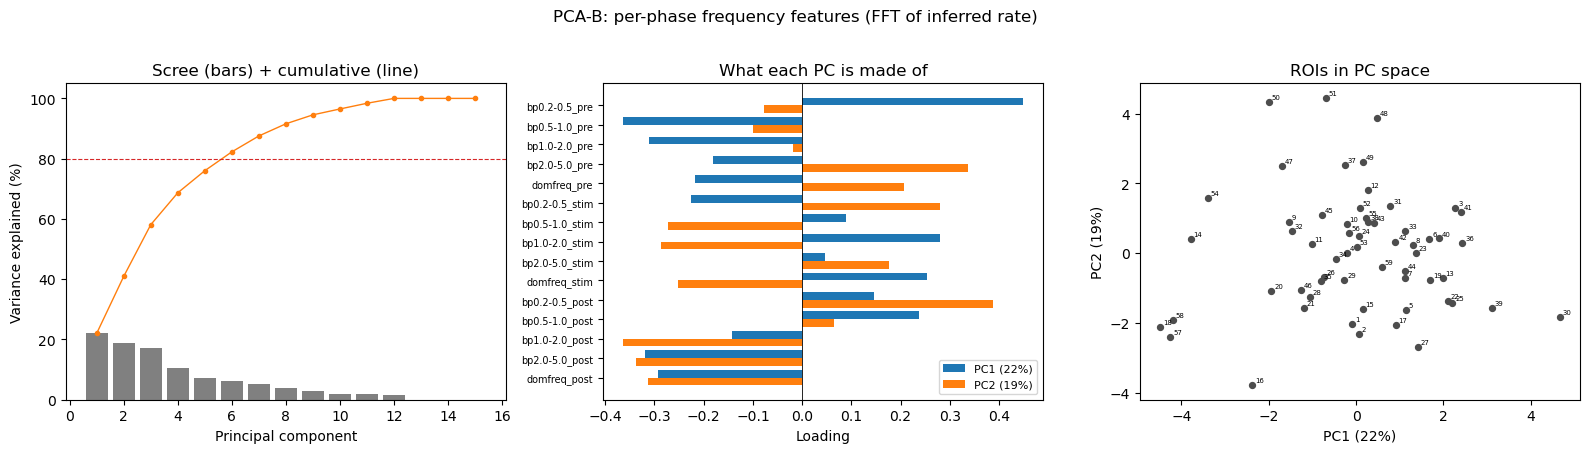


> Candidate cuts (pick one for FREQ_CUT_HEIGHT below, or accept the auto choice):
   height   gap  smallest  largest                       sizes
k                                                             
2   14.14  1.23        17       42                    [42, 17]
3   12.86  1.34         8       42                  [42, 9, 8]
4   11.98  0.41         8       32              [32, 10, 9, 8]
5   10.53  2.49         3       32           [32, 10, 8, 6, 3]
6    8.53  1.50         3       29        [29, 10, 8, 6, 3, 3]
7    7.74  0.09         3       29     [29, 10, 6, 5, 3, 3, 3]
8    7.49  0.42         3       20  [20, 10, 9, 6, 5, 3, 3, 3]


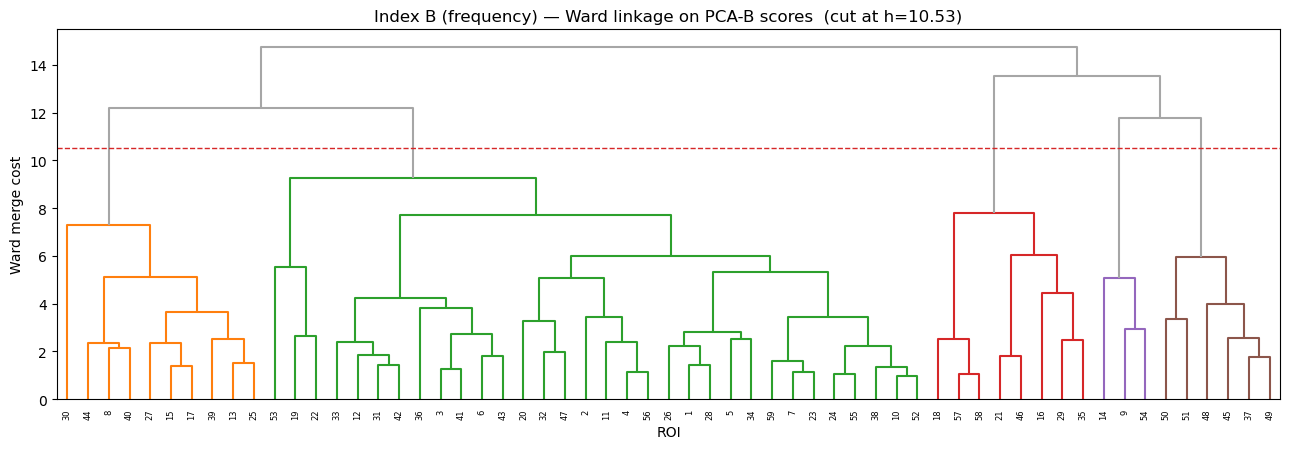

> Cut at h=10.53 -> 5 frequency group(s): F1 n=10, F2 n=32, F3 n=8, F4 n=3, F5 n=6

=== Frequency groups (Index B) ===
FFT of CASCADE inferred rate | Spinal_cord_excitatory_30Hz_smoothing50ms | bands [(0.2, 0.5), (0.5, 1.0), (1.0, 2.0), (2.0, 5.0)] Hz
       n_rois  domfreq_pre topband_pre  domfreq_stim topband_stim  domfreq_post topband_post
group                                                                                       
F1         10        0.250  0.2-0.5 Hz         0.920   0.5-1.0 Hz         0.477   0.2-0.5 Hz
F2         32        0.270  0.2-0.5 Hz         0.425   0.2-0.5 Hz         0.441   0.2-0.5 Hz
F3          8        0.250  0.2-0.5 Hz         0.525   0.5-1.0 Hz         1.614   2.0-5.0 Hz
F4          3        0.875  0.5-1.0 Hz         0.467   0.5-1.0 Hz         0.400   0.2-0.5 Hz
F5          6        0.375  0.2-0.5 Hz         0.400   0.2-0.5 Hz         0.357   0.2-0.5 Hz
  F1: ROIs 8, 13, 15, 17, 25, 27, 30, 39, 40, 44
  F2: ROIs 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 19, 

In [128]:
# §5 x. PCA-B on the frequency features, cut the tree the same way, then read the
# frequency grouping against the rate grouping from §5 viii.
from sklearn.metrics import adjusted_rand_score

pca_freq, scores_freq, npc_freq, Z_freq = pca_and_linkage(freq_features)
print(f"> PCA-B: {freq_features.shape[1]} features -> {npc_freq} PC(s) "
      f"for {100 * pca_freq.explained_variance_ratio_[:npc_freq].sum():.0f}% of variance")

plot_pca_summary(pca_freq, scores_freq, freq_features,
                 "PCA-B: per-phase frequency features (FFT of inferred rate)")

print("\n> Candidate cuts (pick one for FREQ_CUT_HEIGHT below, or accept the auto choice):")
print(cut_candidates(Z_freq).to_string())

FREQ_CUT_HEIGHT = None  # set a number (see the table above) to cut manually

cut_freq = FREQ_CUT_HEIGHT if FREQ_CUT_HEIGHT is not None else suggest_cut(Z_freq)
plot_dendrogram(Z_freq, "Index B (frequency) — Ward linkage on PCA-B scores", cut_freq)

freq_groups = fcluster(Z_freq, cut_freq, criterion="distance")
print(f"> Cut at h={cut_freq:.2f} -> {freq_groups.max()} frequency group(s): "
      + ", ".join(f"F{g} n={int((freq_groups == g).sum())}" for g in range(1, freq_groups.max() + 1)))

# Per-group frequency profile: dominant frequency + which band carries most power.
freq_summary_rows = []
for g in range(1, freq_groups.max() + 1):
    sel = freq_groups == g
    row = {"group": f"F{g}", "n_rois": int(sel.sum())}
    for name in PHASE_ORDER:
        row[f"domfreq_{name}"] = freq_features[sel][f"domfreq_{name}"].mean()
        band_means = {f"{lo}-{hi}": freq_features[sel][f"bp{lo}-{hi}_{name}"].mean()
                      for lo, hi in FREQ_BANDS}
        row[f"topband_{name}"] = max(band_means, key=band_means.get) + " Hz"
    freq_summary_rows.append(row)
freq_summary = pd.DataFrame(freq_summary_rows).set_index("group").round(3)

print("\n=== Frequency groups (Index B) ===")
print(f"FFT of CASCADE inferred rate | {MODEL_NAME} | bands {FREQ_BANDS} Hz")
print(freq_summary.to_string())
for g in range(1, freq_groups.max() + 1):
    members = [str(roi_ids[i]) for i in np.flatnonzero(freq_groups == g)]
    print(f"  F{g}: ROIs {', '.join(members)}")

# Do the two indices carve up the population the same way?
contingency = pd.crosstab(
    pd.Series([f"G{g}" for g in rate_groups], name="rate group"),
    pd.Series([f"F{g}" for g in freq_groups], name="freq group"),
)
ari = adjusted_rand_score(rate_groups, freq_groups)
print("\n=== Rate groups vs frequency groups ===")
print(contingency.to_string())
print(f"\n> Adjusted Rand index = {ari:.3f}  "
      "(1 = identical partitions, ~0 = no more agreement than chance)")
print("> High agreement: when a neuron responds also predicts how fast it fluctuates.")
print("> Low agreement: the two indices carry independent information about the population.")

freq_features.to_csv(ANALYSIS_DIR / "freq_features.csv")
pd.DataFrame({"roi": roi_ids, "rate_group": rate_groups, "freq_group": freq_groups}).to_csv(
    ANALYSIS_DIR / "roi_groups.csv", index=False)
print(f"\n> Saved freq_features.csv and roi_groups.csv -> {ANALYSIS_DIR}")


### xi. Caveats — read before quoting any number above

- **Single trial, n = 1 per neuron per phase.** Everything above is descriptive. There are no
  repeats to average over, so no inferential statistic applies and no p-value should be
  attached to any group difference.
- **CASCADE was trained on cortical V1 GCaMP8 (DS30–32).** No paired Ca²⁺/ephys ground truth
  exists for DRG (CLAUDE.md App.A §8), so this cross-cell-type transfer is *untested*. Report
  **relative** or **burst** rate — never absolute spike counts.
- **Acquisition sets the ceiling, not the algorithm.** 10 Hz sampling → 5 Hz Nyquist. The 5 s
  stimulus phase gives 0.2 Hz frequency resolution, so anything slower than 0.2 Hz is
  invisible *within that phase by construction*, not absent from the biology.
- **Resampling to reach a model's training rate creates no new information.** Running a 30 Hz
  model means the 10 Hz traces are interpolated 3×; the extra frames are a smooth function of
  the real ones. The model sees a signal cleaner than anything in its training set, and the
  inferred rate is resampled straight back to 10 Hz. Temporal resolution remains 10 Hz
  throughout. Noise levels are measured *before* resampling for exactly this reason — measured
  after, they read ~3× too clean and every ROI is routed to the wrong ensemble.
- **The post phase contains the indicator decay tail** of the stimulus response. Elevated
  post-stimulus values are not by themselves evidence of new firing. Deconvolving to a rate
  before summarising mitigates this; it does not eliminate it.
- **F0 = mean of the first `BASELINE_SLIDES` frames (0–2 s)**, so pre-phase features are taken
  from 2–10 s. A fixed F0 also bakes photobleaching drift into dF/F as a slow ramp.
- **ΔF/F amplitude is not a rate proxy** (CLAUDE.md App.A §11). The `dff_*` columns are
  descriptive only and are deliberately excluded from both PCAs.
- **Inference-target ambiguity.** For a DRG soma, T-junction filtering means the inferred rate
  is closer to a *somatic-invasion* rate than to the peripheral spike train (CLAUDE.md App.A
  §9/§11) — and the two diverge exactly at the high rates of interest.
- **A group is not a cell type.** These are response-pattern groups from one recording, not
  molecularly or physiologically defined classes.

vi. Create a non-directional weighted graph with ROI as nodes and the distance on PCA as edges. Sort nodes by distance.

## **-. Archive**

`4. i.`

In [ ]:
'''# STD projection: highlights temporally-fluctuating (active) pixels better than
# the max projection, which only shows consistently-bright pixels. Subsampled
# the same way as the max projection (every 5th frame) -- the per-frame
# denoise+motion-correction pipeline is too expensive to reduce over all 3220
# frames. Computed eagerly (unlike preprocessed_max_stack) because the same
# array is reused for saving + histogramming below.
preprocessed_std_stack = preprocessed_stack[::5].std(axis=0).compute()
print("> STD projection complete:", preprocessed_std_stack.shape, preprocessed_std_stack.dtype)

viewer.add_image(preprocessed_std_stack, name="preprocessed_std")'''

> STD projection complete: (1024, 1376) float32


<Image layer 'preprocessed_std' at 0x3078c2110>

> Saved STD projection -> /Users/leolopster/Desktop/spike_inference/_projections/Debi_DRG_std_projection.tiff


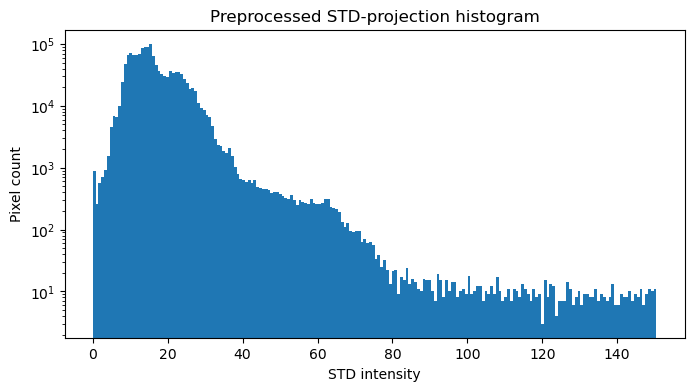

In [ ]:
'''# Save the STD projection locally and check its intensity distribution.

PROJECTIONS_DIR = Path("/Users/leolopster/Desktop/spike_inference/_projections")
PROJECTIONS_DIR.mkdir(exist_ok=True)

dataset_tag = data_dir.name.split("-")[0]  # "Debi_DRG" from "Debi_DRG-Streamtodisk-...imgdir"
std_projection_path = PROJECTIONS_DIR / f"{dataset_tag}_std_projection.tiff"

tifffile.imwrite(std_projection_path, preprocessed_std_stack)
print(f"> Saved STD projection -> {std_projection_path}")

# QC: pixel-intensity distribution, used to pick contrast/threshold before
# manually painting ROIs on top of this layer.
plt.figure(figsize=(8, 4))
plt.hist(preprocessed_std_stack.ravel(), bins=200)
plt.yscale('log')
plt.xlabel("STD intensity")
plt.ylabel("Pixel count")
plt.title("Preprocessed STD-projection histogram")
plt.show()'''

`4. iv.`

In [ ]:
### Deprecated. Use mean fluorescence of the first N-seconds as F0 instead.
'''
# dF/F per ROI using a rolling low-percentile baseline (CLAUDE.md 3): F0(t) is
# the BASELINE_PERCENTILE-th percentile of the ROI's own trace over a sliding
# ~BASELINE_WINDOW_S window, so slow drift / photobleaching across the ~5 min
# recording is tracked rather than baked into a single fixed baseline.
from scipy.ndimage import percentile_filter

BASELINE_PERCENTILE = 8   # low percentile approximates the inactive-baseline level
BASELINE_WINDOW_S = 45    # rolling window length (s)


def compute_dff(trace, times_s, percentile=BASELINE_PERCENTILE, window_s=BASELINE_WINDOW_S):
    dt = np.median(np.diff(times_s))
    win = max(3, int(round(window_s / dt)))
    f0 = percentile_filter(trace, percentile=percentile, size=win, mode="nearest")
    # preprocessed traces are background-subtracted + clipped at 0, so F0 can sit
    # near zero; floor it to keep dF/F finite.
    f0 = np.clip(f0, 1e-3, None)
    return (trace - f0) / f0


roi_ids = sorted(roi_traces)
dff_traces = {roi_id: compute_dff(roi_traces[roi_id], times_s) for roi_id in roi_ids}
dff_matrix = np.vstack([dff_traces[roi_id] for roi_id in roi_ids])  # (n_rois, n_timepoints)
print(f"> Computed dF/F for {len(roi_ids)} ROI(s); "
      f"dF/F range [{dff_matrix.min():.2f}, {dff_matrix.max():.2f}]")
'''


> Computed dF/F for 59 ROI(s); dF/F range [-0.12, 1.16]
